# Final MHT → MWIS → Neutral-Atom Notebook
## Exact classical baseline vs proposed hybrid classical–neutral-atom solution
### Datasets: controlled synthetic tracking data and a small RADIATE `tiny_foggy` radar subset

This notebook is the final end-to-end experimental workflow for the summer-school challenge.

It compares **two solvers on the same MHT conflict graph**:

1. **Fully classical**: filtering → gating → candidate tracks → conflict graph → exact MILP MWIS → final tracking hypothesis.
2. **Hybrid classical–quantum**: the same classical tracking front-end → connected ambiguity components → neutral-atom MWIS with Pulser for small components, with explicit classical fallback for components that are too large or produce no feasible sampled solution.

It evaluates both approaches on **two data sources**:

- **Synthetic data**: We generate mathematical 2D target trajectories and then generate point detections from them by adding Gaussian position noise, missed detections, and clutter. The figures in this notebook are visualizations of those numerical tracks and detections.
- **RADIATE**: we use a short `tiny_foggy` sequence. The actual Cartesian radar `.png` images are visualized, but the MHT tracker receives only the centres of annotated radar bounding boxes as unlabelled 2D detections. Persistent annotation IDs are hidden from the tracker and used only for evaluation.

The notebook also contains:

- a **measurement-noise sweep** for the synthetic data;
- visualization of filtering/gating, candidate tracks, conflict graph, QUBO, exact solution, atom layout, interaction matrix, pulse sequence, and output bitstrings;
- **top-K global hypotheses** rather than only the single MWIS optimum;
- an optional slightly larger synthetic stress test.

> **Experimental principle:** the classical and hybrid branches must see the **same conflict graph**. Otherwise the comparison is not meaningful.

> **v2.2 RADIATE synchronization fix.** The earlier executed run selected annotation frames 46–49 while only 18 local `Navtech_Cartesian` PNGs were available. This version explicitly checks annotation/image availability and restricts automatic window selection to the overlap for which radar PNG visualization is possible. If PNGs are absent, tracking can still run from annotations, but image visualization is skipped.


## 0. Experimental matrix

| Dataset | Fully classical branch | Proposed hybrid branch |
|---|---|---|
| Synthetic point detections | Exact binary MILP MWIS | Pulser neutral-atom MWIS on small components + classical fallback |
| RADIATE radar subset | Exact binary MILP MWIS | Pulser neutral-atom MWIS on small components + classical fallback |

For the quantum branch, we separately report the **raw quantum result** (feasible probability, optimal probability, bitstring distribution, embedding quality) even when the operational hybrid pipeline later falls back to the exact classical solver. This avoids hiding failures of the neutral-atom mapping.

## 1. Imports, versions, and run controls

In [1]:
from __future__ import annotations

import itertools
import json
import math
import os
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx as nx

from matplotlib.patches import Ellipse, Polygon
from scipy.optimize import milp, LinearConstraint, Bounds, minimize
from scipy.spatial.distance import pdist, squareform
from scipy.special import logsumexp

from IPython.display import display

# Pulser is optional until the hybrid section. This notebook still runs the
# complete classical pipeline if Pulser is unavailable.
try:
    import pulser
    import pulser_simulation
    PULSER_AVAILABLE = True
    print("Pulser available:", getattr(pulser, "__version__", "installed"))
except Exception as exc:
    PULSER_AVAILABLE = False
    pulser = None
    pulser_simulation = None
    print("Pulser is not available in this kernel. Classical sections will still run.")
    print("Install with: pip install pulser")
    print("Import error:", exc)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NetworkX:", nx.__version__)

Pulser available: 1.9.0
NumPy: 2.5.2
Pandas: 3.0.5
NetworkX: 3.6.1


In [2]:
# ----------------------------- USER CONTROLS -----------------------------
RUN_QUANTUM = True
MAX_QUANTUM_NODES = 10        # local state-vector emulation; raise cautiously
QUANTUM_DURATION_NS = 40_000  # follows the Pulser MWIS tutorial starting point
EMBEDDING_RESTARTS = 6
EMBEDDING_MAXITER = 50_000

# Your current local RADIATE sample path. You can instead set the environment
# variable RADIATE_SEQUENCE_PATH before launching Jupyter.
RADIATE_SEQUENCE_PATH = Path(
    os.environ.get(
        "RADIATE_SEQUENCE_PATH",
        "/Users/sqgh94@durham.ac.uk/Downloads/NBQSS/v2/tiny_foggy",
    )
)

# Baseline reproduces the compact experiment. Change to "stress" for a
# slightly larger real-data instance after the baseline works.
RADIATE_PROFILE = "baseline"   # "baseline" or "stress"
RADIATE_WINDOW_MODE = "busy"   # "busy" or "crowded"

# Noise sweep is classical by default because repeating Qutip simulations over
# many noise values/trials is expensive and is not needed to study the effect
# of sensor measurement noise on MHT ambiguity.
RUN_NOISE_SWEEP = True
NOISE_SWEEP_TRIALS = 20

## 2. Common data structures

A `Detection` is one observation at one scan. The tracker sees its position `z`; `gt_id` is **evaluation-only**.

A `TrackHypothesis` is one candidate story for an initiating detection. It stores the entire sequence of assigned detections, the current Kalman state/covariance, and a cumulative log-likelihood-ratio score.

In [3]:
@dataclass
class Detection:
    frame: int
    local_id: int
    z: np.ndarray
    gt_id: Optional[str] = None       # evaluation ONLY
    meta: dict = field(default_factory=dict)

    @property
    def key(self):
        return (self.frame, self.local_id)


@dataclass
class TrackHypothesis:
    hid: int
    family_id: int
    history: tuple                   # Detection or None for each scan
    x: np.ndarray                    # [px, py, vx, vy]
    P: np.ndarray
    llr: float
    consecutive_misses: int = 0

    @property
    def used_detection_keys(self):
        return frozenset(d.key for d in self.history if d is not None)

    @property
    def gt_ids(self):
        return [d.gt_id for d in self.history if d is not None and d.gt_id is not None]

    @property
    def first_class(self):
        for d in self.history:
            if d is not None:
                return d.meta.get("class_name")
        return None

# Part I — Shared classical MHT front-end

The **same front-end** is used by the classical and hybrid solvers:

$$
Z_{1:k}
\rightarrow \text{state prediction}
\rightarrow \text{gating}
\rightarrow \text{candidate-track branching}
\rightarrow \text{LLR scoring}
\rightarrow G=(V,E).
$$

Only the solver for the resulting MWIS differs.

## 3. Synthetic data methodology — tracks and point detections, not images

The synthetic generator creates ground-truth trajectories in a 2D plane. For target \(i\), a nominal position evolves from an initial position and velocity, with a small deterministic curvature term so that the Kalman model is not perfectly matched to the data.

At every scan:

1. the true target position is computed;
2. with probability \(P_D\), a detection is produced;
3. Gaussian measurement noise \(\varepsilon\sim\mathcal N(0,\sigma_z^2 I)\) is added;
4. a Poisson number of uniformly distributed clutter detections is added;
5. the detections are shuffled so target identity is not encoded by list order.

Thus the data are numerical points such as

$$
Z_k=\{(x_1,y_1),(x_2,y_2),\ldots\},
$$

not pixels. We *plot* these points to make them visually understandable.

In [4]:
def generate_synthetic_scans(
    n_targets=3,
    n_frames=5,
    dt=1.0,
    measurement_std=0.55,
    p_detection=0.95,
    clutter_rate=0.6,
    area=(-4.0, 14.0, -3.0, 13.0),
    seed=11,
):
    """Generate crossing 2D trajectories plus noisy point detections.

    Returns
    -------
    scans : list[list[Detection]]
        Unlabelled detections presented to MHT. `gt_id` is retained only so we
        can evaluate the result after the tracker has made its decisions.
    truths : dict[str, list[np.ndarray]]
        Noise-free ground-truth trajectory of each synthetic target.
    """
    rng = np.random.default_rng(seed)

    # Deliberately crossing / nearby paths generate association ambiguity.
    initial = [
        (np.array([0.0, 1.0]),  np.array([ 2.0,  1.05])),
        (np.array([10.0, 1.0]), np.array([-2.0,  1.00])),
        (np.array([5.2, 11.0]), np.array([ 0.0, -1.80])),
        (np.array([1.0, 9.0]),  np.array([ 1.35, -0.55])),
    ]
    if n_targets > len(initial):
        raise ValueError(f"n_targets must be <= {len(initial)} for this compact generator.")

    truths = {f"T{i}": [] for i in range(n_targets)}
    scans = []
    xmin, xmax, ymin, ymax = area

    for k in range(n_frames):
        frame_dets = []

        for i in range(n_targets):
            p0, v = initial[i]
            accel = np.array([
                0.05 * np.sin(0.8 * k + i),
                0.04 * np.cos(0.6 * k + i),
            ])
            true_p = p0 + v * (k * dt) + 0.5 * accel * (k * dt) ** 2
            truths[f"T{i}"].append(true_p.copy())

            if rng.random() <= p_detection:
                measured = true_p + rng.normal(0.0, measurement_std, size=2)
                frame_dets.append(
                    Detection(
                        frame=k,
                        local_id=-1,
                        z=measured.astype(float),
                        gt_id=f"T{i}",
                        meta={"kind": "target", "class_name": "target"},
                    )
                )

        # False alarms / clutter have no target ground-truth ID.
        for _ in range(rng.poisson(clutter_rate)):
            frame_dets.append(
                Detection(
                    frame=k,
                    local_id=-1,
                    z=np.array([rng.uniform(xmin, xmax), rng.uniform(ymin, ymax)]),
                    gt_id=None,
                    meta={"kind": "clutter", "class_name": "clutter"},
                )
            )

        # Shuffle to ensure array/list order does not encode the correct identity.
        rng.shuffle(frame_dets)
        for j, det in enumerate(frame_dets):
            det.local_id = j
        scans.append(frame_dets)

    return scans, truths

### Visualization helper: synthetic truth and observed scans

In [5]:
def plot_scans(scans, truths=None, title="Unlabelled detections", annotate=True):
    plt.figure(figsize=(7, 7))

    if truths is not None:
        for tid, pts in truths.items():
            pts = np.asarray(pts)
            plt.plot(pts[:, 0], pts[:, 1], "--", linewidth=1.5, label=f"truth {tid}")

    for k, frame in enumerate(scans):
        if not frame:
            continue
        Z = np.vstack([d.z for d in frame])
        plt.scatter(Z[:, 0], Z[:, 1], s=45, label=f"scan {k}")
        if annotate:
            for d in frame:
                plt.annotate(f"{k}:{d.local_id}", d.z, fontsize=8)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.legend(loc="best", fontsize=8)
    plt.show()

## 4. Constant-velocity Kalman filtering

The hidden state is

$$
x_k=[p_x,p_y,v_x,v_y]^T.
$$

Only position is measured. The Kalman filter supplies both a predicted position and its uncertainty; the latter is essential for statistically meaningful gating.

In [6]:
def make_kf_matrices(dt=1.0, process_std=0.6, measurement_std=0.7):
    F = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ], dtype=float)

    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ], dtype=float)

    q = process_std ** 2
    Q = q * np.array([
        [dt**4/4, 0, dt**3/2, 0],
        [0, dt**4/4, 0, dt**3/2],
        [dt**3/2, 0, dt**2, 0],
        [0, dt**3/2, 0, dt**2],
    ], dtype=float)

    R = (measurement_std ** 2) * np.eye(2)
    return F, H, Q, R


def initialize_track(z, measurement_std=0.7, initial_velocity_std=4.0):
    x = np.array([z[0], z[1], 0.0, 0.0], dtype=float)
    P = np.diag([
        measurement_std**2,
        measurement_std**2,
        initial_velocity_std**2,
        initial_velocity_std**2,
    ])
    return x, P


def kf_predict(x, P, F, Q):
    return F @ x, F @ P @ F.T + Q


def innovation(z, x_pred, P_pred, H, R):
    nu = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    return nu, S


def mahalanobis_sq(nu, S):
    return float(nu.T @ np.linalg.solve(S, nu))


def gaussian_logpdf_zero(nu, S):
    m = len(nu)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        raise ValueError("Innovation covariance must be positive definite.")
    quad = float(nu.T @ np.linalg.solve(S, nu))
    return -0.5 * (quad + logdet + m * np.log(2 * np.pi))


def kf_update(x_pred, P_pred, z, H, R):
    nu, S = innovation(z, x_pred, P_pred, H, R)
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ nu
    P_upd = (np.eye(len(x_pred)) - K @ H) @ P_pred
    return x_upd, P_upd, nu, S

## 5. Visualizing the first gating step

In [7]:
def covariance_gate_ellipse(mean, S, gamma):
    """Return width, height, angle for nu^T S^-1 nu <= gamma."""
    vals, vecs = np.linalg.eigh(S)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    width, height = 2.0 * np.sqrt(gamma * vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return width, height, angle


def visualize_first_gating_step(
    scans,
    dt,
    process_std,
    measurement_std,
    gate_threshold,
    title="First prediction/gating transition",
):
    """Visualize scan-0 track predictions and which scan-1 detections pass each gate."""
    if len(scans) < 2 or not scans[0]:
        print("Need two non-empty scans for gating visualization.")
        return

    F, H, Q, R = make_kf_matrices(dt, process_std, measurement_std)

    plt.figure(figsize=(8, 7))
    if scans[1]:
        Z1 = np.vstack([d.z for d in scans[1]])
        plt.scatter(Z1[:, 0], Z1[:, 1], marker="x", s=70, label="new detections (scan 1)")
        for d in scans[1]:
            plt.annotate(f"1:{d.local_id}", d.z, fontsize=8)

    for det0 in scans[0]:
        x0, P0 = initialize_track(det0.z, measurement_std)
        xp, Pp = kf_predict(x0, P0, F, Q)
        mean = H @ xp
        S = H @ Pp @ H.T + R
        width, height, angle = covariance_gate_ellipse(mean, S, gate_threshold)

        plt.scatter([mean[0]], [mean[1]], s=45)
        plt.annotate(f"pred {det0.local_id}", mean, fontsize=8)
        ax = plt.gca()
        ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, linewidth=1.2))

        for det1 in scans[1]:
            nu, _ = innovation(det1.z, xp, Pp, H, R)
            if mahalanobis_sq(nu, S) <= gate_threshold:
                plt.plot([mean[0], det1.z[0]], [mean[1], det1.z[1]], alpha=0.45)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title + f"; gate threshold = {gate_threshold}")
    plt.axis("equal")
    plt.legend(loc="best", fontsize=8)
    plt.show()

## 6. MHT branching, missed detections, pruning, and LLR scoring

For a detection branch,

$$
\Delta\mathrm{LLR}
=\log P_D+\log\mathcal N(\nu;0,S)-\log\beta_{FA}.
$$

A missed-detection branch adds $\log(1-P_D)$. Each initiating detection defines one **family** of competing track stories; after each scan only the best `top_k_per_family` branches are kept.

This compact implementation is intentionally a proof-of-concept: tracks are initiated from the first scan and new births are not initiated later in the window.

In [8]:
def build_candidate_hypotheses(
    scans,
    dt=1.0,
    process_std=0.6,
    measurement_std=0.7,
    p_detection=0.95,
    beta_fa=1e-3,
    gate_threshold=9.21,
    top_k_per_family=6,
    max_consecutive_misses=1,
    enforce_class_consistency=False,
):
    if len(scans) < 2:
        raise ValueError("Use at least two scans.")
    if not scans[0]:
        raise ValueError("The first scan must contain at least one initiating detection.")

    F, H, Q, R = make_kf_matrices(dt, process_std, measurement_std)
    hid_counter = itertools.count()
    families = {}

    # One family per first-scan detection.
    for family_id, det in enumerate(scans[0]):
        x, P = initialize_track(det.z, measurement_std)
        families[family_id] = [
            TrackHypothesis(
                hid=next(hid_counter),
                family_id=family_id,
                history=(det,),
                x=x,
                P=P,
                llr=0.0,
            )
        ]

    for frame_idx in range(1, len(scans)):
        detections = scans[frame_idx]
        new_families = {}

        for family_id, branches in families.items():
            candidates = []

            for h in branches:
                x_pred, P_pred = kf_predict(h.x, h.P, F, Q)
                expected_class = h.first_class

                # Detection-assignment branches.
                for det in detections:
                    if enforce_class_consistency:
                        det_class = det.meta.get("class_name")
                        if expected_class and det_class and expected_class != det_class:
                            continue

                    nu, S = innovation(det.z, x_pred, P_pred, H, R)
                    d2 = mahalanobis_sq(nu, S)

                    if d2 <= gate_threshold:
                        x_upd, P_upd, _, _ = kf_update(x_pred, P_pred, det.z, H, R)
                        dllr = (
                            np.log(p_detection)
                            + gaussian_logpdf_zero(nu, S)
                            - np.log(beta_fa)
                        )
                        candidates.append(
                            TrackHypothesis(
                                hid=next(hid_counter),
                                family_id=family_id,
                                history=h.history + (det,),
                                x=x_upd,
                                P=P_upd,
                                llr=h.llr + float(dllr),
                                consecutive_misses=0,
                            )
                        )

                # Missed-detection branch.
                if h.consecutive_misses < max_consecutive_misses:
                    candidates.append(
                        TrackHypothesis(
                            hid=next(hid_counter),
                            family_id=family_id,
                            history=h.history + (None,),
                            x=x_pred,
                            P=P_pred,
                            llr=h.llr + float(np.log(max(1e-15, 1.0 - p_detection))),
                            consecutive_misses=h.consecutive_misses + 1,
                        )
                    )

            candidates.sort(key=lambda h: h.llr, reverse=True)
            new_families[family_id] = candidates[:top_k_per_family]

        families = new_families

    return [h for branches in families.values() for h in branches]


def hypothesis_table(hypotheses, limit=50):
    rows = []
    for h in sorted(hypotheses, key=lambda z: z.llr, reverse=True)[:limit]:
        rows.append({
            "hid": h.hid,
            "family": h.family_id,
            "LLR": h.llr,
            "history": [None if d is None else d.key for d in h.history],
            "GT ids (evaluation only)": h.gt_ids,
        })
    return pd.DataFrame(rows)


def plot_candidate_tracks(hypotheses, title="Candidate track hypotheses"):
    plt.figure(figsize=(8, 7))
    for h in hypotheses:
        pts = np.array([d.z for d in h.history if d is not None])
        if len(pts) == 0:
            continue
        plt.plot(pts[:, 0], pts[:, 1], marker="o", alpha=0.55)
        plt.annotate(f"h{h.hid}", pts[-1], fontsize=7)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.show()

## 7. Candidate tracks → weighted conflict graph

Each final candidate track is a vertex. Two candidate tracks conflict if either:

- they belong to the **same family** (alternative stories for one initiating detection), or
- they claim at least one **same measurement**.

The vertex weight is the candidate track's accumulated LLR.

In [9]:
def build_conflict_graph(hypotheses, positive_only=True):
    Hs = [h for h in hypotheses if (h.llr > 0 if positive_only else True)]
    G = nx.Graph()

    for h in Hs:
        G.add_node(h.hid, weight=float(h.llr), hypothesis=h)

    for a, b in itertools.combinations(Hs, 2):
        same_family = a.family_id == b.family_id
        shared_detection = bool(a.used_detection_keys & b.used_detection_keys)
        if same_family or shared_detection:
            G.add_edge(a.hid, b.hid)

    return G


def draw_conflict_graph(G, title="MHT conflict graph"):
    if len(G) == 0:
        print("Graph is empty.")
        return
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=4)
    labels = {n: f"h{n}\nw={G.nodes[n]['weight']:.1f}" for n in G.nodes}
    nx.draw_networkx(G, pos, labels=labels, node_size=1150, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.show()


def independent_set_weight(G, selected):
    return float(sum(G.nodes[n]["weight"] for n in selected))


def is_independent_set(G, selected):
    S = set(selected)
    return all(not (u in S and v in S) for u, v in G.edges)

# Part II — Approach A: fully classical final solution

The exact classical branch solves the MWIS as a **binary mixed-integer linear program (MILP)**:

$$
\max_x \sum_i w_i x_i,
\qquad x_i+x_j\le 1\;\;\forall(i,j)\in E,
\qquad x_i\in\{0,1\}.
$$

The implementation uses `scipy.optimize.milp`. Connected components are solved independently and their solutions are combined. Brute-force enumeration is kept only for small-instance verification and for producing top-K hypotheses.

## 8. Exact MILP MWIS and top-K classical hypotheses

In [10]:
def solve_mwis_bruteforce(G, max_nodes=24):
    nodes = list(G.nodes)
    n = len(nodes)
    if n > max_nodes:
        raise ValueError(f"Brute force disabled for n={n}; max_nodes={max_nodes}.")

    best_set, best_w = set(), 0.0
    for mask in range(1 << n):
        chosen = {nodes[i] for i in range(n) if (mask >> i) & 1}
        if is_independent_set(G, chosen):
            w = independent_set_weight(G, chosen)
            if w > best_w + 1e-12:
                best_set, best_w = chosen, w
    return best_set, best_w


def solve_mwis_milp(G):
    nodes = list(G.nodes)
    n = len(nodes)
    if n == 0:
        return set(), 0.0, 0.0

    idx = {node: i for i, node in enumerate(nodes)}
    weights = np.array([G.nodes[node]["weight"] for node in nodes], dtype=float)

    rows = []
    for u, v in G.edges:
        row = np.zeros(n)
        row[idx[u]] = 1.0
        row[idx[v]] = 1.0
        rows.append(row)

    constraints = ()
    if rows:
        A = np.vstack(rows)
        constraints = LinearConstraint(A, -np.inf * np.ones(len(rows)), np.ones(len(rows)))

    tic = time.perf_counter()
    res = milp(
        c=-weights,                         # scipy minimizes; negate to maximize
        integrality=np.ones(n),             # binary/integer variables
        bounds=Bounds(np.zeros(n), np.ones(n)),
        constraints=constraints,
        options={"disp": False},
    )
    elapsed = time.perf_counter() - tic

    if not res.success:
        raise RuntimeError(f"MILP failed: {res.message}")

    bits = np.rint(res.x).astype(int)
    selected = {nodes[i] for i, bit in enumerate(bits) if bit == 1}
    return selected, independent_set_weight(G, selected), elapsed


def solve_graph_classically(G):
    selected_all = set()
    rows = []

    components = list(nx.connected_components(G)) if len(G) else []
    for cidx, comp_nodes in enumerate(components):
        SG = G.subgraph(comp_nodes).copy()
        selected, weight, runtime_s = solve_mwis_milp(SG)
        selected_all |= selected
        rows.append({
            "component": cidx,
            "nodes": SG.number_of_nodes(),
            "edges": SG.number_of_edges(),
            "solver": "exact MILP",
            "selected": sorted(selected),
            "weight": weight,
            "runtime_s": runtime_s,
        })

    total_weight = independent_set_weight(G, selected_all)
    return selected_all, total_weight, pd.DataFrame(rows)


def top_k_classical_hypotheses(G, k=10, max_nodes=22):
    """Enumerate top-K feasible global independent sets for the small graphs used here."""
    nodes = list(G.nodes)
    if len(nodes) > max_nodes:
        raise ValueError(f"Top-K enumeration disabled for n={len(nodes)} > {max_nodes}.")

    rows = []
    for bits in itertools.product([0, 1], repeat=len(nodes)):
        selected = {nodes[i] for i, b in enumerate(bits) if b}
        if not is_independent_set(G, selected):
            continue
        weight = independent_set_weight(G, selected)
        rows.append({
            "bitstring": "".join(map(str, bits)),
            "selected": selected,
            "weight": weight,
        })

    rows.sort(key=lambda r: r["weight"], reverse=True)
    rows = rows[:k]
    df = pd.DataFrame(rows)

    # Relative likelihood-like ranking from the global score. This is NOT the
    # same object as the quantum sampling probability.
    if len(df):
        scores = df["weight"].to_numpy(float)
        df["relative_score_mass"] = np.exp(scores - logsumexp(scores))
    return df

## 9. QUBO construction and visualization

In [11]:
def build_qubo(G, penalty=None):
    nodes = list(G.nodes)
    idx = {node: i for i, node in enumerate(nodes)}
    weights = np.array([G.nodes[n]["weight"] for n in nodes], dtype=float)

    if penalty is None:
        # Simple sufficient choice for positive MWIS weights.
        penalty = (weights.max() + 1.0) if len(weights) else 1.0

    Q = np.zeros((len(nodes), len(nodes)), dtype=float)
    for i, w in enumerate(weights):
        Q[i, i] = -w
    for u, v in G.edges:
        i, j = idx[u], idx[v]
        Q[i, j] += penalty / 2.0
        Q[j, i] += penalty / 2.0
    return nodes, Q, float(penalty)


def qubo_energy(bits, Q):
    x = np.asarray(bits, dtype=float)
    return float(x @ Q @ x)


def validate_qubo_small(G, max_nodes=20):
    nodes, Q, penalty = build_qubo(G)
    if len(nodes) > max_nodes:
        return {"checked": False, "reason": f"n={len(nodes)} > {max_nodes}"}

    best_E, best_bits = np.inf, None
    for bits in itertools.product([0, 1], repeat=len(nodes)):
        E = qubo_energy(bits, Q)
        if E < best_E:
            best_E, best_bits = E, bits

    selected = {nodes[i] for i, b in enumerate(best_bits) if b}
    exact, exact_w = solve_mwis_bruteforce(G, max_nodes=max_nodes)
    return {
        "checked": True,
        "penalty": penalty,
        "qubo_selected": selected,
        "qubo_energy": best_E,
        "exact_mwis": exact,
        "exact_weight": exact_w,
        "same_weight": abs(independent_set_weight(G, selected) - exact_w) < 1e-9,
    }


def plot_matrix(M, labels=None, title="Matrix", colorbar_label=None):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(M, aspect="auto")
    plt.title(title)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    cb = plt.colorbar(im)
    if colorbar_label:
        cb.set_label(colorbar_label)
    plt.tight_layout()
    plt.show()


def plot_qubo(G, title="QUBO matrix"):
    nodes, Q, penalty = build_qubo(G)
    plot_matrix(Q, labels=[f"h{n}" for n in nodes], title=f"{title}; penalty={penalty:.2f}")

## 10. Evaluation and track visualizations

In [12]:
def selected_hypothesis_table(G, selected):
    rows = []
    for n in sorted(selected):
        h = G.nodes[n]["hypothesis"]
        rows.append({
            "vertex": n,
            "family": h.family_id,
            "weight": h.llr,
            "history": [None if d is None else d.key for d in h.history],
            "GT ids (evaluation only)": h.gt_ids,
        })
    return pd.DataFrame(rows)


def identity_metrics(G, selected):
    rows = []
    for n in sorted(selected):
        h = G.nodes[n]["hypothesis"]
        ids = h.gt_ids
        if ids:
            counts = Counter(ids)
            purity = max(counts.values()) / len(ids)
            switches = sum(a != b for a, b in zip(ids[:-1], ids[1:]))
            dominant = counts.most_common(1)[0][0]
        else:
            purity, switches, dominant = np.nan, np.nan, None

        rows.append({
            "vertex": n,
            "weight": h.llr,
            "n_labeled_detections": len(ids),
            "dominant_gt_id": dominant,
            "identity_purity": purity,
            "identity_switches": switches,
        })
    return pd.DataFrame(rows)


def plot_selected_tracks(G, selected, title="Selected global hypothesis"):
    plt.figure(figsize=(8, 7))
    for n in sorted(selected):
        h = G.nodes[n]["hypothesis"]
        pts = np.array([d.z for d in h.history if d is not None])
        if len(pts) == 0:
            continue
        plt.plot(pts[:, 0], pts[:, 1], marker="o", linewidth=2.2, label=f"h{n}, w={h.llr:.2f}")
        for d in h.history:
            if d is not None:
                plt.annotate(f"{d.frame}:{d.local_id}", d.z, fontsize=8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    if selected:
        plt.legend(loc="best", fontsize=8)
    plt.show()


def summarize_solution(name, G, selected, exact_weight=None):
    weight = independent_set_weight(G, selected)
    metrics = identity_metrics(G, selected)
    return {
        "experiment": name,
        "graph_nodes": G.number_of_nodes(),
        "graph_edges": G.number_of_edges(),
        "largest_component": max((len(c) for c in nx.connected_components(G)), default=0),
        "selected_tracks": len(selected),
        "solution_weight": weight,
        "ratio_to_exact": (weight / exact_weight) if exact_weight and exact_weight > 0 else np.nan,
        "mean_track_purity": metrics["identity_purity"].mean() if len(metrics) else np.nan,
        "total_identity_switches": metrics["identity_switches"].sum() if len(metrics) else np.nan,
    }

# Part III — Approach B: hybrid classical–neutral-atom solution

For each connected ambiguity component:

1. one graph vertex \(\leftrightarrow\) one atom;
2. graph incompatibilities are approximated by Rydberg interactions \(V_{ij}\propto R_{ij}^{-6}\);
3. positive vertex weights are encoded with a Detuning Map Modulator (DMM);
4. an adiabatic sequence is simulated with `QutipBackendV2`;
5. sampled bitstrings are decoded into candidate tracks.

The atom-coordinate optimizer below intentionally follows the current Pulser MWIS tutorial structure. It is a **heuristic**, not a universal graph encoder. Therefore we explicitly visualize and quantify the mismatch between the desired conflict adjacency and the physical interaction matrix.

The operational hybrid branch uses a classical fallback only when a component is too large for the configured emulator limit or when the quantum run produces **no feasible sampled independent set**. The raw quantum failure is retained and reported.

## 11. Graph → neutral-atom geometry and embedding diagnostics

In [13]:
def adjacency_and_weights(G):
    nodes = list(G.nodes)
    A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
    w = np.array([G.nodes[n]["weight"] for n in nodes], dtype=float)
    return nodes, A, w


def optimize_rydberg_embedding(
    G,
    device=None,
    restarts=EMBEDDING_RESTARTS,
    seed=3,
    maxiter=EMBEDDING_MAXITER,
):
    """Heuristic coordinate fit mirroring the Pulser MWIS tutorial.

    We minimize ||V - A||_F, where V_ij = interaction_coeff / R_ij^6 / 4
    and A is the off-diagonal conflict adjacency matrix.
    """
    if device is None:
        if not PULSER_AVAILABLE:
            raise RuntimeError("Pulser is required for the device interaction coefficient.")
        device = pulser.MockDevice

    nodes, A, _ = adjacency_and_weights(G)
    n = len(nodes)
    if n < 2:
        raise ValueError("Embedding is only needed for components with >= 2 vertices.")

    target = A.copy()
    np.fill_diagonal(target, 0.0)
    coeff = float(device.interaction_coeff)
    rng = np.random.default_rng(seed)

    edge_distance = (coeff / 4.0) ** (1.0 / 6.0)

    def objective(flat):
        coords = np.asarray(flat).reshape(n, 2)
        distances = pdist(coords)
        if len(distances) and np.min(distances) < 0.15 * edge_distance:
            return 1e8
        V = squareform(coeff / distances**6) / 4.0
        return float(np.linalg.norm(V - target))

    best = None
    for _ in range(restarts):
        x0 = rng.uniform(-edge_distance, edge_distance, size=(n, 2)).ravel()
        res = minimize(
            objective,
            x0,
            method="Nelder-Mead",
            options={"maxiter": maxiter, "xatol": 1e-5, "fatol": 1e-5},
        )
        if best is None or res.fun < best.fun:
            best = res

    coords = best.x.reshape(n, 2)
    D = squareform(pdist(coords))
    V = np.zeros_like(D)
    mask = D > 0
    V[mask] = coeff / (D[mask] ** 6) / 4.0

    upper = np.triu(np.ones_like(target, dtype=bool), 1)
    edge_mask = upper & (target > 0)
    nonedge_mask = upper & (target == 0)
    edge_vals = V[edge_mask]
    nonedge_vals = V[nonedge_mask]

    min_edge = float(edge_vals.min()) if len(edge_vals) else np.nan
    max_nonedge = float(nonedge_vals.max()) if len(nonedge_vals) else 0.0
    separation_ratio = (
        float(min_edge / max_nonedge)
        if len(edge_vals) and max_nonedge > 0
        else np.inf if len(edge_vals) else np.nan
    )

    norm_target = np.linalg.norm(target)
    normalized_loss = float(best.fun / norm_target) if norm_target > 0 else 0.0

    return {
        "nodes": nodes,
        "coords": coords,
        "distance_matrix": D,
        "interaction_matrix": V,
        "target_adjacency": target,
        "loss": float(best.fun),
        "normalized_loss": normalized_loss,
        "min_edge_interaction": min_edge,
        "max_nonedge_interaction": max_nonedge,
        "edge_nonedge_separation": separation_ratio,
        "edge_distance_scale": edge_distance,
        "optimizer": best,
    }


def plot_embedding_diagnostics(embedding, G, title_prefix="Neutral-atom mapping", device=None):
    if device is None and PULSER_AVAILABLE:
        device = pulser.MockDevice

    coords = embedding["coords"]
    nodes = embedding["nodes"]
    node_to_i = {n: i for i, n in enumerate(nodes)}

    # 1) Atom positions with the DESIRED MHT conflict edges overlaid.
    plt.figure(figsize=(7, 6))
    for i, n in enumerate(nodes):
        plt.scatter(coords[i, 0], coords[i, 1], s=140)
        plt.text(coords[i, 0], coords[i, 1], f"  h{n}")
    for u, v in G.edges:
        i, j = node_to_i[u], node_to_i[v]
        plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]], "--", alpha=0.55)
    plt.axis("equal")
    plt.xlabel("x [µm]")
    plt.ylabel("y [µm]")
    plt.title(
        f"{title_prefix}: atom positions\n"
        f"normalized embedding loss={embedding['normalized_loss']:.3f}, "
        f"edge/non-edge separation={embedding['edge_nonedge_separation']:.2f}"
    )
    plt.show()

    # 2) Desired adjacency.
    plot_matrix(
        embedding["target_adjacency"],
        labels=[f"h{n}" for n in nodes],
        title=f"{title_prefix}: desired conflict adjacency",
    )

    # 3) Physical interaction matrix produced by the atom positions.
    plot_matrix(
        embedding["interaction_matrix"],
        labels=[f"h{n}" for n in nodes],
        title=f"{title_prefix}: physical C6/R^6 interaction matrix (scaled)",
    )

    # 4) Residual: this makes unwanted non-edge interactions and weak edges visible.
    residual = embedding["interaction_matrix"] - embedding["target_adjacency"]
    plot_matrix(
        residual,
        labels=[f"h{n}" for n in nodes],
        title=f"{title_prefix}: physical - desired interaction residual",
    )

    # 5) Pulser's own register/blockade visualization when available.
    if PULSER_AVAILABLE and device is not None:
        qubits = {f"q{i}": coords[i] for i in range(len(nodes))}
        reg = pulser.Register(qubits)
        try:
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(1.0),
                draw_graph=True,
                draw_half_radius=True,
            )
            plt.show()
        except Exception as exc:
            print("Pulser register drawing skipped:", exc)

## 12. Weighted Pulser sequence and quantum component solver

In [14]:
def build_pulser_mwis_sequence(G, embedding, duration_ns=QUANTUM_DURATION_NS, device=None):
    if not PULSER_AVAILABLE:
        raise RuntimeError("Install Pulser before running this cell.")
    if device is None:
        device = pulser.MockDevice

    nodes = embedding["nodes"]
    coords = embedding["coords"]
    qubits = {f"q{i}": coords[i] for i in range(len(nodes))}

    reg = pulser.Register(qubits)
    seq = pulser.Sequence(reg, device)
    seq.declare_channel("rydberg_global", "rydberg_global")

    # DMM weight mapping from the Pulser MWIS tutorial:
    # highest graph weight -> zero additional DMM penalty.
    weights = np.array([G.nodes[n]["weight"] for n in nodes], dtype=float)
    if np.any(weights <= 0):
        raise ValueError("Only positive MWIS weights are sent to Pulser in this notebook.")
    norm_w = weights / weights.max()
    det_map_weights = 1.0 - norm_w
    det_map = reg.define_detuning_map(
        {f"q{i}": float(det_map_weights[i]) for i in range(len(nodes))}
    )
    seq.config_detuning_map(det_map, "dmm_0")

    # Tutorial heuristic: set the drive scale using the strongest interaction
    # between vertices that should NOT be connected.
    nonedge_distances = []
    for i in range(len(nodes)):
        for j in range(i):
            if not G.has_edge(nodes[i], nodes[j]):
                nonedge_distances.append(float(np.linalg.norm(coords[i] - coords[j])))

    if nonedge_distances:
        omega = float(device.interaction_coeff / min(nonedge_distances) ** 6 * 10.0)
    else:
        # Complete-graph fallback: the tutorial expression has no non-edge pair.
        pair_d = pdist(coords)
        omega = float(device.interaction_coeff / np.min(pair_d) ** 6 * 0.25)

    delta_0 = -omega
    delta_f = omega
    T = int(duration_ns)

    adiabatic_pulse = pulser.Pulse(
        pulser.InterpolatedWaveform(T, [1e-9, omega, 1e-9]),
        pulser.InterpolatedWaveform(T, [delta_0, 0.0, delta_f]),
        0.0,
    )
    seq.add(adiabatic_pulse, "rydberg_global")
    seq.add_dmm_detuning(pulser.ConstantWaveform(T, -delta_f), "dmm_0")

    return seq, reg, {
        "omega": omega,
        "delta_0": delta_0,
        "delta_f": delta_f,
        "duration_ns": T,
        "detuning_map_weights": det_map_weights,
    }


def bitstring_to_selected(bitstring, nodes):
    return {nodes[i] for i, b in enumerate(bitstring) if b == "1"}


def run_quantum_mwis_component(
    G,
    duration_ns=QUANTUM_DURATION_NS,
    embedding_restarts=EMBEDDING_RESTARTS,
    embedding_maxiter=EMBEDDING_MAXITER,
):
    if not PULSER_AVAILABLE:
        raise RuntimeError("Pulser is not installed.")

    tic = time.perf_counter()
    embedding = optimize_rydberg_embedding(
        G,
        restarts=embedding_restarts,
        maxiter=embedding_maxiter,
    )
    seq, reg, pulse_info = build_pulser_mwis_sequence(
        G,
        embedding,
        duration_ns=duration_ns,
    )

    backend = pulser_simulation.QutipBackendV2(seq)
    results = backend.run()
    elapsed = time.perf_counter() - tic
    distribution = dict(results.final_bitstrings)

    total_mass = float(sum(distribution.values()))
    rows = []
    for bitstring, mass in distribution.items():
        selected = bitstring_to_selected(bitstring, embedding["nodes"])
        feasible = is_independent_set(G, selected)
        weight = independent_set_weight(G, selected) if feasible else np.nan
        probability = float(mass) / total_mass if total_mass else 0.0
        rows.append({
            "bitstring": bitstring,
            "probability": probability,
            "feasible": feasible,
            "weight": weight,
            "selected": selected,
        })

    table = pd.DataFrame(rows).sort_values("probability", ascending=False)
    feasible_table = table[table["feasible"]].copy()

    if feasible_table.empty:
        chosen_set = set()
        chosen_weight = 0.0
        chosen_bitstring = None
    else:
        # The quantum result is chosen WITHOUT consulting the classical optimum:
        # use the most-probable feasible sampled bitstring.
        row = feasible_table.iloc[0]
        chosen_set = set(row["selected"])
        chosen_weight = float(row["weight"])
        chosen_bitstring = row["bitstring"]

    return {
        "selected": chosen_set,
        "weight": chosen_weight,
        "bitstring": chosen_bitstring,
        "distribution": table,
        "embedding": embedding,
        "sequence": seq,
        "register": reg,
        "pulse_info": pulse_info,
        "runtime_s": elapsed,
        "feasible_probability": float(table.loc[table["feasible"], "probability"].sum()),
    }


def add_exact_quantum_metrics(detail, exact_weight, atol=1e-8):
    table = detail["distribution"].copy()
    mask = table["feasible"] & np.isclose(table["weight"].astype(float), exact_weight, atol=atol)
    detail["optimal_probability"] = float(table.loc[mask, "probability"].sum())
    detail["exact_component_weight"] = float(exact_weight)
    return detail


def plot_quantum_distribution(detail, title="Quantum bitstring distribution", top_n=15):
    table = detail["distribution"].head(top_n).copy()
    plt.figure(figsize=(9, 5))
    plt.bar(table["bitstring"], table["probability"])
    plt.xticks(rotation=90)
    plt.ylabel("sample probability")
    plt.xlabel("bitstring")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 13. Operational hybrid solver over ambiguity components

In [15]:
def solve_graph_hybrid(
    G,
    max_quantum_nodes=MAX_QUANTUM_NODES,
    duration_ns=QUANTUM_DURATION_NS,
    fallback_if_no_feasible=True,
):
    """Hybrid component routing.

    * n=1: trivial classical decision.
    * 2 <= n <= max_quantum_nodes: attempt neutral-atom solver.
    * n > max_quantum_nodes: exact classical fallback.
    * if the QPU/emulator samples no feasible independent set, keep the raw
      quantum diagnostics but optionally fall back classically for the final
      operational answer.
    """
    selected_all = set()
    component_rows = []
    quantum_details = {}

    components = list(nx.connected_components(G)) if len(G) else []
    for cidx, comp_nodes in enumerate(components):
        SG = G.subgraph(comp_nodes).copy()
        n = SG.number_of_nodes()
        exact_set, exact_w, _ = solve_mwis_milp(SG)  # reference for metrics/fallback

        if n == 1:
            selected, weight = exact_set, exact_w
            solver = "classical-trivial"
            quantum_attempted = False

        elif n <= max_quantum_nodes and PULSER_AVAILABLE and RUN_QUANTUM:
            detail = run_quantum_mwis_component(SG, duration_ns=duration_ns)
            detail = add_exact_quantum_metrics(detail, exact_w)
            quantum_details[cidx] = detail
            quantum_attempted = True

            if detail["bitstring"] is None and fallback_if_no_feasible:
                selected, weight = exact_set, exact_w
                solver = "classical-fallback-after-no-feasible-quantum-sample"
            else:
                selected, weight = detail["selected"], detail["weight"]
                solver = "neutral-atom/Pulser"

        else:
            selected, weight = exact_set, exact_w
            solver = "classical-fallback-size-or-no-Pulser"
            quantum_attempted = False

        selected_all |= set(selected)
        component_rows.append({
            "component": cidx,
            "nodes": n,
            "edges": SG.number_of_edges(),
            "solver": solver,
            "quantum_attempted": quantum_attempted,
            "selected": sorted(selected),
            "weight": weight,
            "exact_component_weight": exact_w,
        })

    total_weight = independent_set_weight(G, selected_all)
    return {
        "selected": selected_all,
        "weight": total_weight,
        "components": pd.DataFrame(component_rows),
        "quantum_details": quantum_details,
    }


def quantum_component_summary(hybrid_result):
    rows = []
    for cidx, detail in hybrid_result["quantum_details"].items():
        emb = detail["embedding"]
        rows.append({
            "component": cidx,
            "atoms": len(emb["nodes"]),
            "embedding_loss": emb["loss"],
            "normalized_embedding_loss": emb["normalized_loss"],
            "edge_nonedge_separation": emb["edge_nonedge_separation"],
            "feasible_probability": detail["feasible_probability"],
            "optimal_probability": detail.get("optimal_probability", np.nan),
            "chosen_bitstring": detail["bitstring"],
            "chosen_weight": detail["weight"],
            "exact_component_weight": detail.get("exact_component_weight", np.nan),
            "runtime_s": detail["runtime_s"],
        })
    return pd.DataFrame(rows)

## 14. Multiple-hypothesis output from quantum samples

MHT is useful precisely because it can retain more than one plausible explanation. The classical side can rank the top-K feasible independent sets. The neutral-atom side naturally returns a distribution of sampled bitstrings.

**Important:** the quantum sampling probability is **not automatically the Bayesian MHT posterior**. We treat it as a sampling/ranking diagnostic unless a calibrated probabilistic relationship is established.

In [16]:
def top_feasible_quantum_samples(detail, k=10):
    df = detail["distribution"]
    return df[df["feasible"]].sort_values("probability", ascending=False).head(k).copy()


def top_k_quantum_global_hypotheses(G, hybrid_result, k_per_component=6, k_global=10):
    """Combine independent component samples into global hypotheses.

    Quantum components contribute their feasible sampled distributions. Components
    handled classically contribute only their selected final solution, so this is a
    complete top-K quantum distribution only when all non-trivial components were
    successfully sampled by Pulser.
    """
    components = list(nx.connected_components(G)) if len(G) else []
    comp_table = hybrid_result["components"].set_index("component")
    options = []

    for cidx, comp_nodes in enumerate(components):
        if cidx in hybrid_result["quantum_details"]:
            qdf = top_feasible_quantum_samples(hybrid_result["quantum_details"][cidx], k_per_component)
            if len(qdf):
                qdf = qdf.copy()
                total = qdf["probability"].sum()
                qdf["conditional_probability"] = qdf["probability"] / total if total > 0 else 0.0
                options.append([
                    {"selected": set(r.selected), "probability": float(r.conditional_probability)}
                    for r in qdf.itertuples()
                ])
                continue

        selected = set(comp_table.loc[cidx, "selected"])
        options.append([{"selected": selected, "probability": 1.0}])

    rows = []
    for combo in itertools.product(*options):
        selected = set()
        probability = 1.0
        for opt in combo:
            selected |= opt["selected"]
            probability *= opt["probability"]
        rows.append({
            "selected": selected,
            "probability": probability,
            "weight": independent_set_weight(G, selected),
        })

    rows.sort(key=lambda r: r["probability"], reverse=True)
    return pd.DataFrame(rows[:k_global])

# Part IV — Experiment A: baseline synthetic data

The baseline synthetic instance is kept small enough to inspect every stage explicitly. It includes crossing trajectories, measurement noise, a high detection probability, and clutter.

Detections per frame: [4, 4, 3, 4]


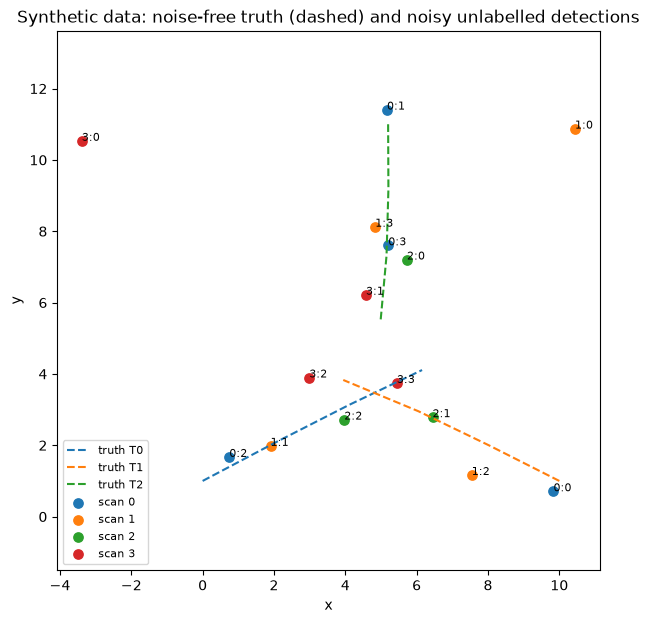

In [17]:
SYNTH_CFG = dict(
    n_targets=3,
    n_frames=4,
    dt=1.0,
    measurement_std=0.55,
    p_detection=0.98,
    clutter_rate=0.6,
    seed=11,
)

SYNTH_MHT_CFG = dict(
    dt=SYNTH_CFG["dt"],
    process_std=0.45,
    measurement_std=SYNTH_CFG["measurement_std"],
    p_detection=SYNTH_CFG["p_detection"],
    beta_fa=1e-3,
    gate_threshold=9.21,
    top_k_per_family=2,
    max_consecutive_misses=1,
    enforce_class_consistency=False,
)

synthetic_scans, synthetic_truth = generate_synthetic_scans(**SYNTH_CFG)
print("Detections per frame:", [len(s) for s in synthetic_scans])
plot_scans(
    synthetic_scans,
    synthetic_truth,
    title="Synthetic data: noise-free truth (dashed) and noisy unlabelled detections",
)

### A1. Filtering and gating visualization

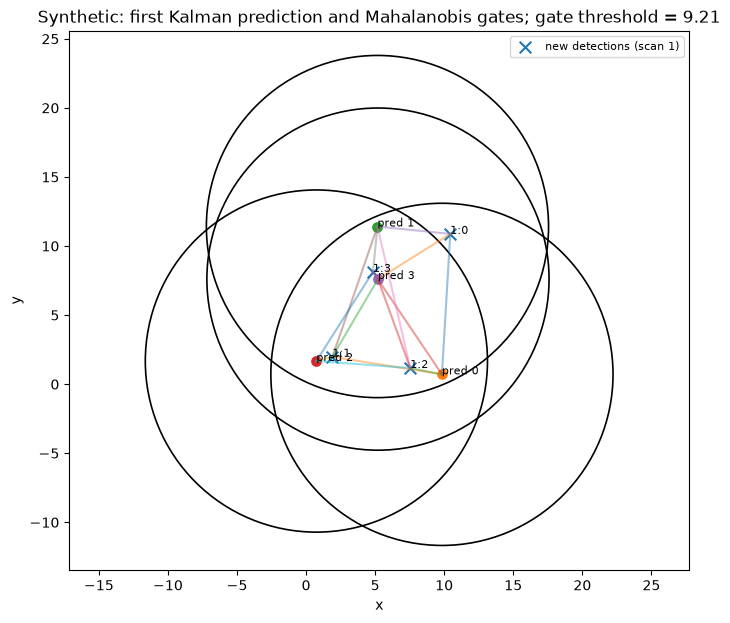

In [18]:
visualize_first_gating_step(
    synthetic_scans,
    dt=SYNTH_MHT_CFG["dt"],
    process_std=SYNTH_MHT_CFG["process_std"],
    measurement_std=SYNTH_MHT_CFG["measurement_std"],
    gate_threshold=SYNTH_MHT_CFG["gate_threshold"],
    title="Synthetic: first Kalman prediction and Mahalanobis gates",
)

### A2. Candidate MHT tracks

Final candidate hypotheses: 8


,hid,family,LLR,history,GT ids (evaluation only)
0,52,2,11.045064,"[(0, 2), (1, 1), (2, 2), (3, 3)]","[T0, T0, T0, T0]"
1,41,0,10.405864,"[(0, 0), (1, 2), (2, 1), (3, 3)]","[T1, T1, T1, T0]"
2,55,3,9.524113,"[(0, 3), (1, 3), (2, 0), (3, 1)]","[T2, T2, T2]"
3,40,0,9.513206,"[(0, 0), (1, 2), (2, 1), (3, 2)]","[T1, T1, T1, T1]"
4,48,1,8.903611,"[(0, 1), (1, 3), (2, 0), (3, 3)]","[T2, T2, T2, T0]"
5,51,2,8.429496,"[(0, 2), (1, 1), (2, 2), (3, 2)]","[T0, T0, T0, T1]"
6,46,1,8.086634,"[(0, 1), (1, 3), (2, 0), (3, 1)]","[T2, T2, T2, T2]"
7,56,3,1.792502,"[(0, 3), (1, 3), (2, 0), None]","[T2, T2]"


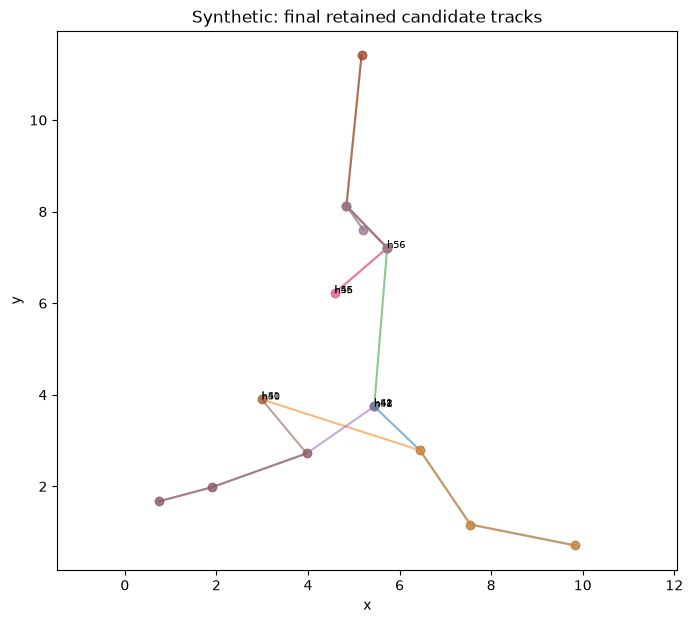

In [19]:
synthetic_hypotheses = build_candidate_hypotheses(synthetic_scans, **SYNTH_MHT_CFG)
print("Final candidate hypotheses:", len(synthetic_hypotheses))
display(hypothesis_table(synthetic_hypotheses, limit=30))
plot_candidate_tracks(synthetic_hypotheses, "Synthetic: final retained candidate tracks")

### A3. Conflict graph

Positive-weight MWIS vertices: 8
Conflict edges: 12
Connected component sizes: [8]


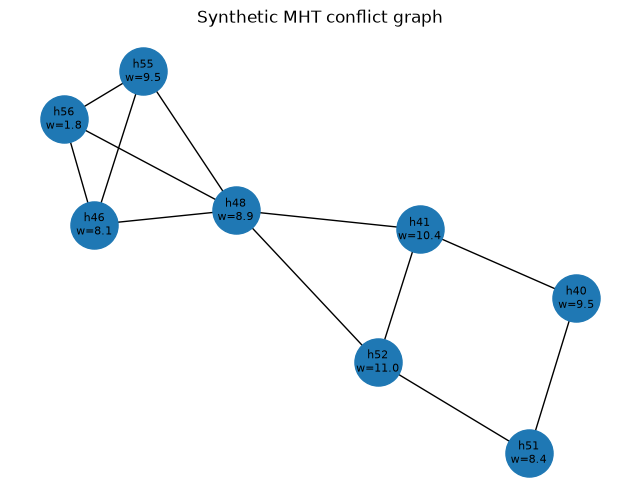

In [20]:
synthetic_G = build_conflict_graph(synthetic_hypotheses, positive_only=True)
print("Positive-weight MWIS vertices:", synthetic_G.number_of_nodes())
print("Conflict edges:", synthetic_G.number_of_edges())
print("Connected component sizes:", sorted([len(c) for c in nx.connected_components(synthetic_G)], reverse=True))
draw_conflict_graph(synthetic_G, "Synthetic MHT conflict graph")

### A4. Exact classical solution and top-K hypotheses

Exact classical MWIS weight: 30.082383633177844


,component,nodes,edges,solver,selected,weight,runtime_s
0,0,8,12,exact MILP,"[40, 52, 55]",30.082384,0.009925


,vertex,family,weight,history,GT ids (evaluation only)
0,40,0,9.513206,"[(0, 0), (1, 2), (2, 1), (3, 2)]","[T1, T1, T1, T1]"
1,52,2,11.045064,"[(0, 2), (1, 1), (2, 2), (3, 3)]","[T0, T0, T0, T0]"
2,55,3,9.524113,"[(0, 3), (1, 3), (2, 0), (3, 1)]","[T2, T2, T2]"


,vertex,weight,n_labeled_detections,dominant_gt_id,identity_purity,identity_switches
0,40,9.513206,4,T1,1.0,0
1,52,11.045064,4,T0,1.0,0
2,55,9.524113,3,T2,1.0,0


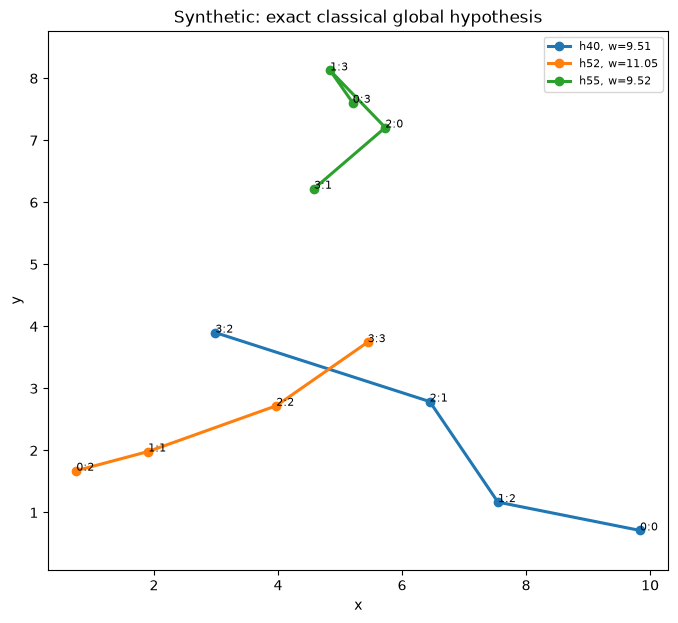

Top classical global hypotheses:


,bitstring,selected,weight,relative_score_mass
0,01001010,"{40, 52, 55}",30.082384,0.685306
1,01011000,"{40, 52, 46}",28.644905,0.162778
2,10000110,"{41, 51, 55}",28.359473,0.122359
3,10010100,"{41, 51, 46}",26.921995,0.029063
4,01001001,"{40, 56, 52}",22.350772,0.000301
5,10000101,"{56, 41, 51}",20.627862,0.000054
6,00001010,"{52, 55}",20.569178,0.000051
7,01001000,"{40, 52}",20.558270,0.000050
8,10000010,"{41, 55}",19.929977,0.000027
9,00011000,"{52, 46}",19.131699,0.000012


In [21]:
synthetic_classical_set, synthetic_classical_w, synthetic_classical_components = solve_graph_classically(synthetic_G)
print("Exact classical MWIS weight:", synthetic_classical_w)
display(synthetic_classical_components)
display(selected_hypothesis_table(synthetic_G, synthetic_classical_set))
display(identity_metrics(synthetic_G, synthetic_classical_set))
plot_selected_tracks(synthetic_G, synthetic_classical_set, "Synthetic: exact classical global hypothesis")

print("Top classical global hypotheses:")
synthetic_topk_classical = top_k_classical_hypotheses(synthetic_G, k=10)
display(synthetic_topk_classical)

### A5. QUBO verification and QUBO visualization

,checked,penalty,qubo_selected,qubo_energy,exact_mwis,exact_weight,same_weight,component
0,True,12.045064,"{40, 52, 55}",-30.082384,"{40, 52, 55}",30.082384,True,0


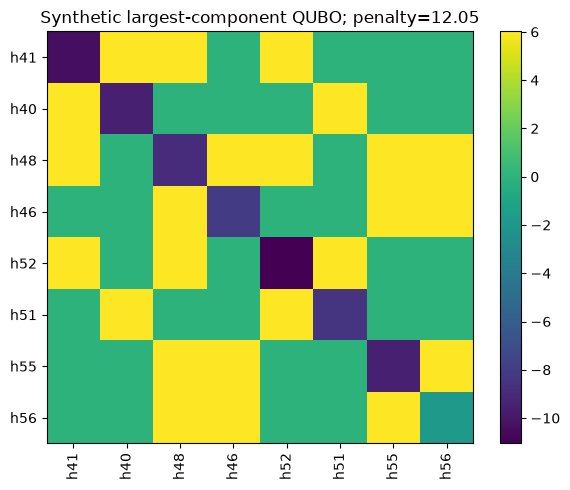

In [22]:
qubo_checks = []
for cidx, comp in enumerate(nx.connected_components(synthetic_G)):
    result = validate_qubo_small(synthetic_G.subgraph(comp).copy(), max_nodes=20)
    result["component"] = cidx
    qubo_checks.append(result)
display(pd.DataFrame(qubo_checks))

# For this compact baseline there is usually one main component.
largest_syn_comp = max(nx.connected_components(synthetic_G), key=len)
plot_qubo(synthetic_G.subgraph(largest_syn_comp).copy(), "Synthetic largest-component QUBO")

### A6. Hybrid neutral-atom solution and visualization of the QC mapping

Operational hybrid solution weight: 30.082383633177844
Ratio to exact classical: 1.0


,component,nodes,edges,solver,quantum_attempted,selected,weight,exact_component_weight
0,0,8,12,classical-fallback-after-no-feasible-quantum-s...,True,"[40, 52, 55]",30.082384,30.082384


,vertex,family,weight,history,GT ids (evaluation only)
0,40,0,9.513206,"[(0, 0), (1, 2), (2, 1), (3, 2)]","[T1, T1, T1, T1]"
1,52,2,11.045064,"[(0, 2), (1, 1), (2, 2), (3, 3)]","[T0, T0, T0, T0]"
2,55,3,9.524113,"[(0, 3), (1, 3), (2, 0), (3, 1)]","[T2, T2, T2]"


Raw quantum-component diagnostics:


,component,atoms,embedding_loss,normalized_embedding_loss,edge_nonedge_separation,feasible_probability,optimal_probability,chosen_bitstring,chosen_weight,exact_component_weight,runtime_s
0,0,8,2.614472,0.533677,0.000027,0.0,0.0,None,0.0,30.082384,2.10298



Synthetic quantum component 0
Most-probable feasible bitstring: None
Feasible probability mass: 0.0
Optimal probability mass: 0.0


,bitstring,probability,feasible,weight,selected
0,11000110,0.798,False,NaN,"{40, 41, 51, 55}"
1,11010100,0.170,False,NaN,"{40, 41, 51, 46}"
2,11010110,0.030,False,NaN,"{40, 41, 46, 51, 55}"
3,11011000,0.001,False,NaN,"{40, 41, 52, 46}"
4,11000100,0.001,False,NaN,"{40, 41, 51}"


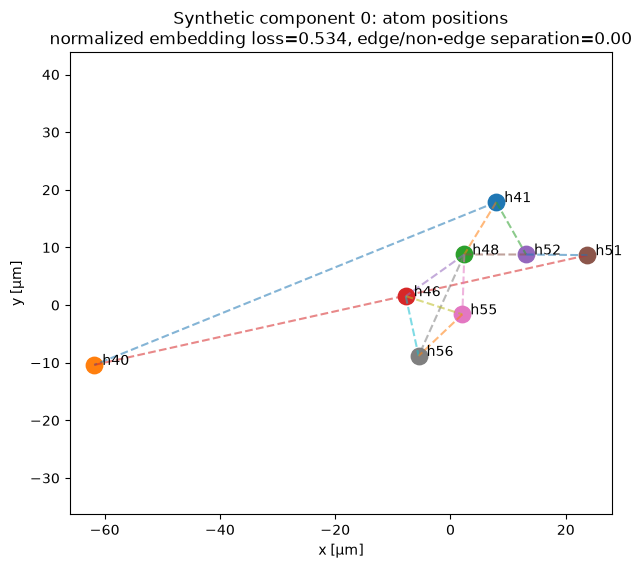

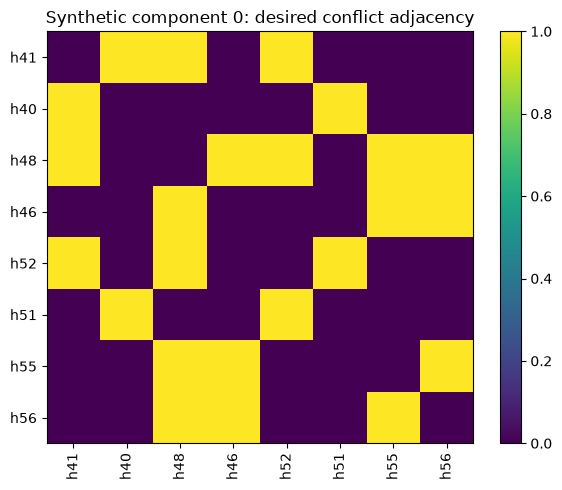

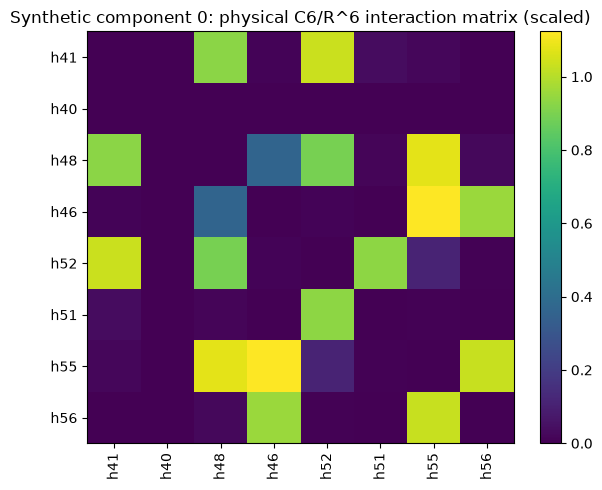

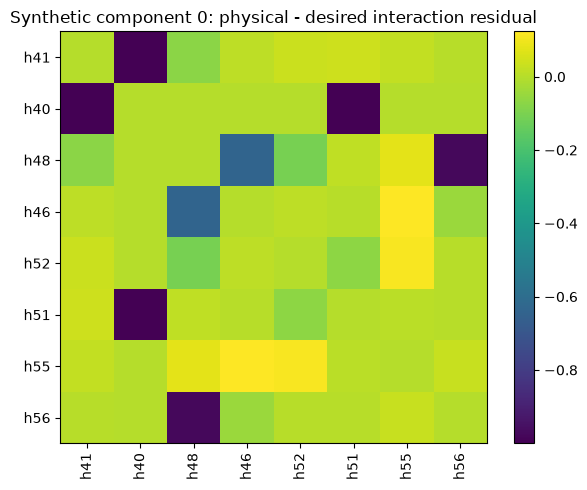

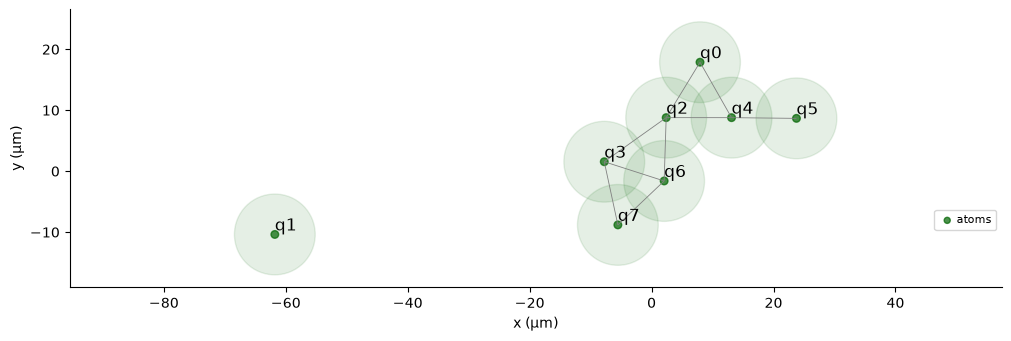

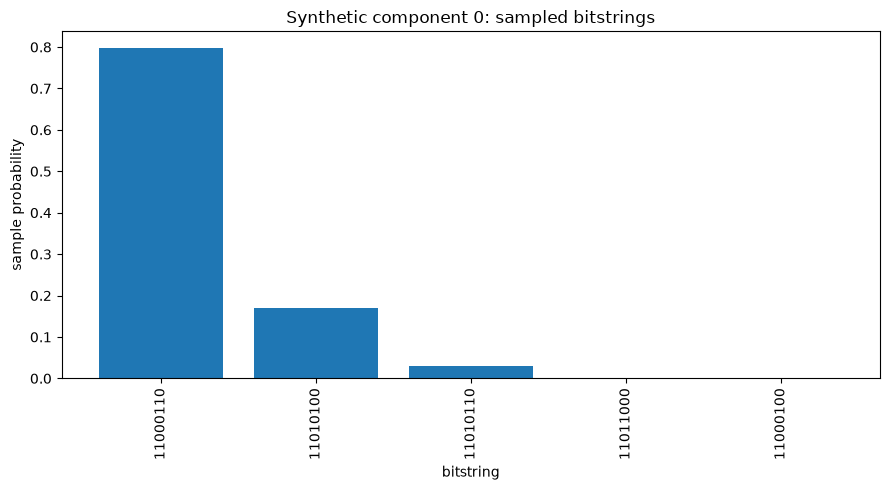

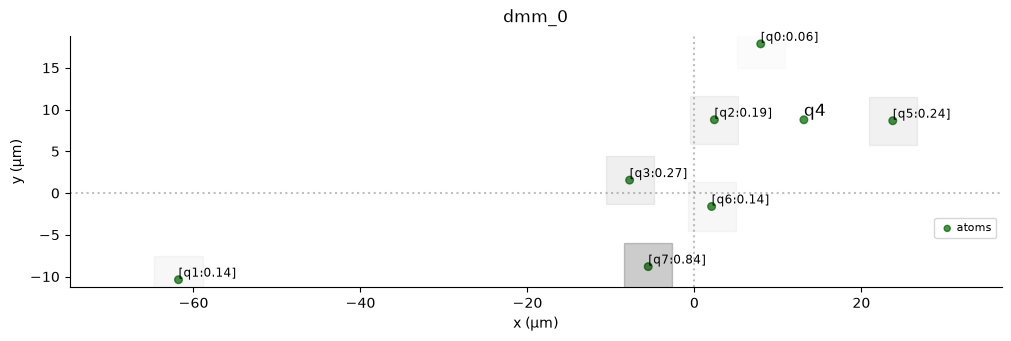

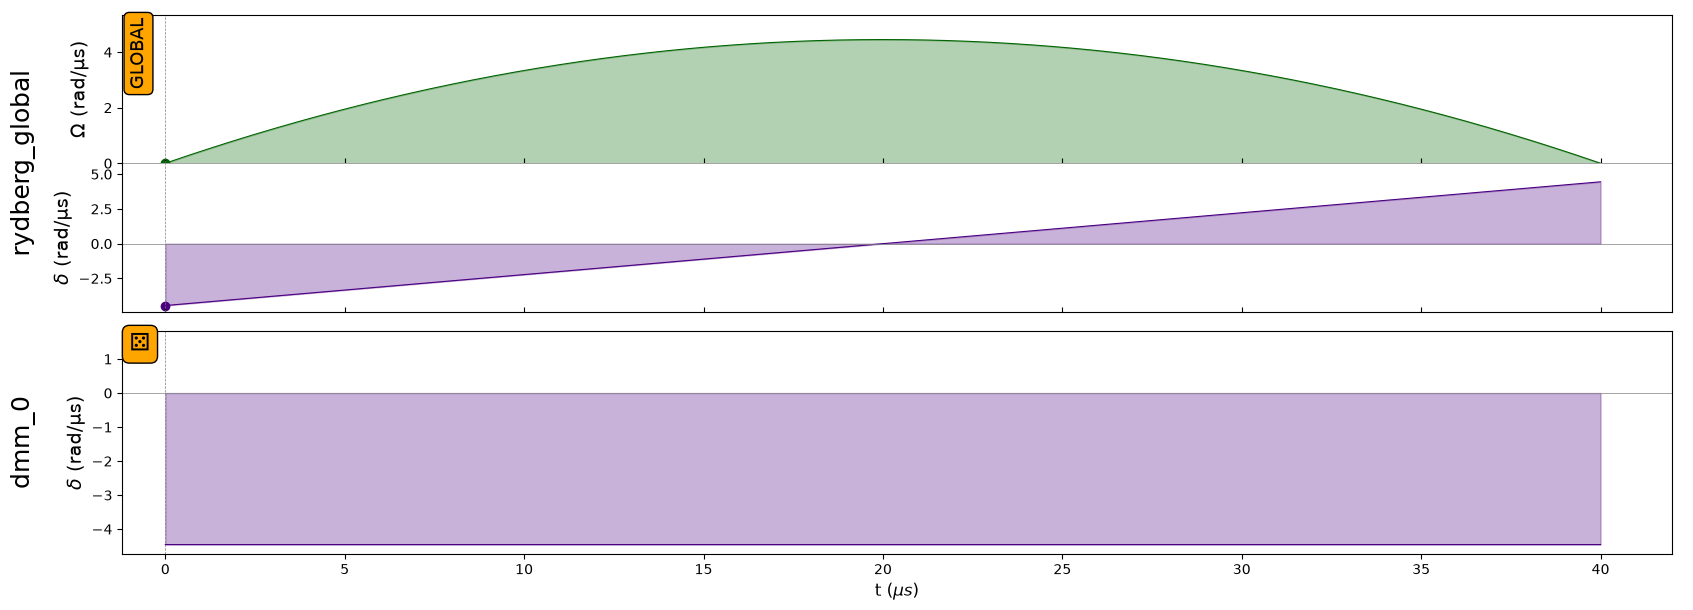

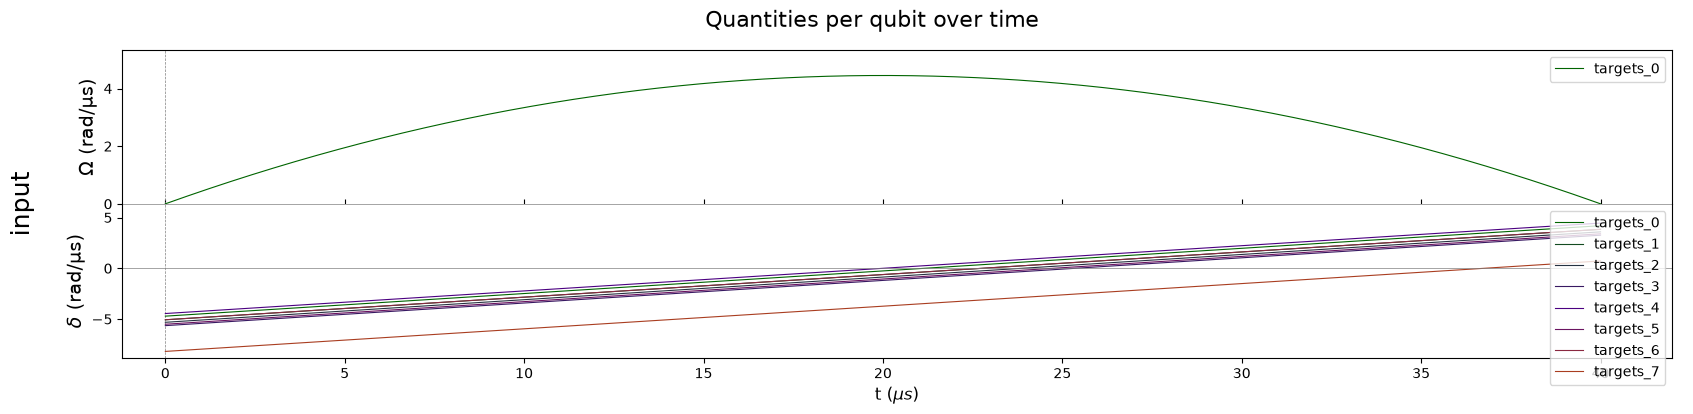

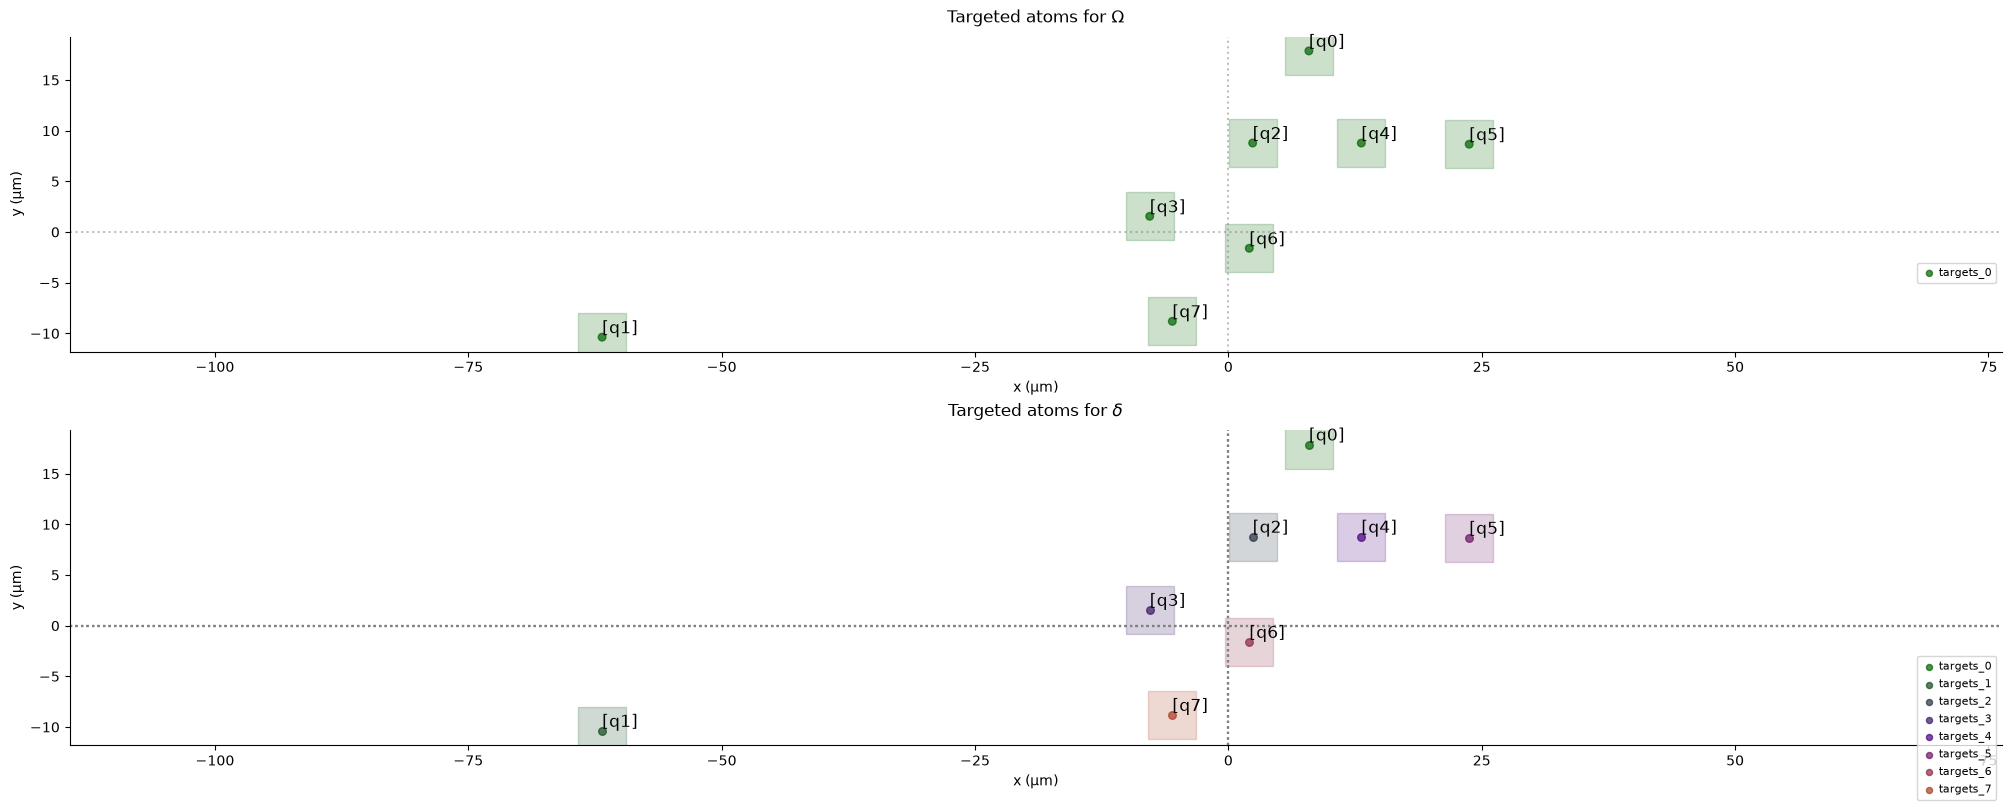

Top global hybrid/quantum hypotheses:


,selected,probability,weight
0,"{40, 52, 55}",1.0,30.082384


In [23]:
if RUN_QUANTUM and PULSER_AVAILABLE:
    synthetic_hybrid = solve_graph_hybrid(
        synthetic_G,
        max_quantum_nodes=MAX_QUANTUM_NODES,
        duration_ns=QUANTUM_DURATION_NS,
        fallback_if_no_feasible=True,
    )
    print("Operational hybrid solution weight:", synthetic_hybrid["weight"])
    print("Ratio to exact classical:", synthetic_hybrid["weight"] / synthetic_classical_w)
    display(synthetic_hybrid["components"])
    display(selected_hypothesis_table(synthetic_G, synthetic_hybrid["selected"]))

    synthetic_components = list(nx.connected_components(synthetic_G))
    qsummary = quantum_component_summary(synthetic_hybrid)
    print("Raw quantum-component diagnostics:")
    display(qsummary)

    for cidx, detail in synthetic_hybrid["quantum_details"].items():
        SG = synthetic_G.subgraph(synthetic_components[cidx]).copy()
        print(f"\nSynthetic quantum component {cidx}")
        print("Most-probable feasible bitstring:", detail["bitstring"])
        print("Feasible probability mass:", detail["feasible_probability"])
        print("Optimal probability mass:", detail.get("optimal_probability"))
        display(detail["distribution"].head(15))

        plot_embedding_diagnostics(detail["embedding"], SG, title_prefix=f"Synthetic component {cidx}")
        plot_quantum_distribution(detail, title=f"Synthetic component {cidx}: sampled bitstrings")

        # Pulser's sequence drawing shows the global Rabi drive, global detuning,
        # and DMM-local detuning experienced by the atoms.
        try:
            detail["sequence"].draw(
                draw_detuning_maps=True,
                draw_qubit_det=True,
                draw_qubit_amp=True,
            )
            plt.show()
        except Exception as exc:
            print("Pulser sequence drawing skipped:", exc)

    print("Top global hybrid/quantum hypotheses:")
    display(top_k_quantum_global_hypotheses(synthetic_G, synthetic_hybrid, k_global=10))
else:
    synthetic_hybrid = None
    print("Quantum synthetic branch skipped (RUN_QUANTUM=False or Pulser unavailable).")

# Part V — Synthetic measurement-noise sweep

This experiment isolates the effect of **measurement noise** \(\sigma_z\). To avoid mixing several effects, the sweep sets `p_detection=1` and `clutter_rate=0`; only the Gaussian measurement standard deviation changes. For each noise value, several random trials are generated.

We measure:

- number of final MWIS vertices and conflict edges (problem/ambiguity size);
- largest connected ambiguity component;
- exact classical track purity;
- number of identity switches;
- fraction of trials that recover a perfect set of three pure, switch-free tracks.

This directly tests how increasing sensor uncertainty changes MHT ambiguity before we even ask the quantum optimizer to solve the graph.

In [24]:
def run_noise_sweep(
    noise_values=(0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0),
    n_trials=20,
    n_targets=3,
    n_frames=5,
):
    rows = []

    for sigma in noise_values:
        for trial in range(n_trials):
            scans, _ = generate_synthetic_scans(
                n_targets=n_targets,
                n_frames=n_frames,
                dt=1.0,
                measurement_std=float(sigma),
                p_detection=1.0,       # isolate measurement noise
                clutter_rate=0.0,      # isolate measurement noise
                seed=1000 + trial,
            )

            hypotheses = build_candidate_hypotheses(
                scans,
                dt=1.0,
                process_std=0.45,
                measurement_std=float(sigma),
                p_detection=0.999,     # practically no miss branch; log remains finite
                beta_fa=1e-3,
                gate_threshold=9.21,
                top_k_per_family=3,
                max_consecutive_misses=0,
                enforce_class_consistency=False,
            )

            G = build_conflict_graph(hypotheses, positive_only=True)
            selected, weight, _ = solve_graph_classically(G)
            metrics = identity_metrics(G, selected)

            mean_purity = metrics["identity_purity"].mean() if len(metrics) else np.nan
            switches = metrics["identity_switches"].sum() if len(metrics) else np.nan
            perfect = bool(
                len(selected) == n_targets
                and np.isclose(mean_purity, 1.0, equal_nan=False)
                and switches == 0
            )

            rows.append({
                "measurement_std": float(sigma),
                "trial": trial,
                "graph_nodes": G.number_of_nodes(),
                "graph_edges": G.number_of_edges(),
                "largest_component": max((len(c) for c in nx.connected_components(G)), default=0),
                "selected_tracks": len(selected),
                "classical_weight": weight,
                "mean_track_purity": mean_purity,
                "identity_switches": switches,
                "perfect_trial": perfect,
            })

    raw = pd.DataFrame(rows)
    summary = raw.groupby("measurement_std").agg(
        graph_nodes_mean=("graph_nodes", "mean"),
        graph_nodes_std=("graph_nodes", "std"),
        graph_edges_mean=("graph_edges", "mean"),
        graph_edges_std=("graph_edges", "std"),
        largest_component_mean=("largest_component", "mean"),
        purity_mean=("mean_track_purity", "mean"),
        purity_std=("mean_track_purity", "std"),
        switches_mean=("identity_switches", "mean"),
        switches_std=("identity_switches", "std"),
        perfect_trial_rate=("perfect_trial", "mean"),
    ).reset_index()

    return raw, summary


def plot_noise_sweep(summary):
    x = summary["measurement_std"].to_numpy()

    plt.figure(figsize=(7, 5))
    plt.plot(x, summary["graph_nodes_mean"], marker="o", label="MWIS vertices")
    plt.plot(x, summary["graph_edges_mean"], marker="o", label="conflict edges")
    plt.xlabel("measurement noise standard deviation")
    plt.ylabel("mean graph size over trials")
    plt.title("Synthetic noise sweep: ambiguity/graph complexity")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(x, summary["purity_mean"], marker="o", label="mean track identity purity")
    plt.plot(x, summary["perfect_trial_rate"], marker="o", label="perfect-trial fraction")
    plt.xlabel("measurement noise standard deviation")
    plt.ylabel("fraction / purity")
    plt.ylim(-0.02, 1.02)
    plt.title("Synthetic noise sweep: association quality")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(x, summary["switches_mean"], marker="o")
    plt.xlabel("measurement noise standard deviation")
    plt.ylabel("mean identity switches")
    plt.title("Synthetic noise sweep: identity switches")
    plt.show()

Noise-sweep summary matrix:


,graph_nodes_mean,graph_edges_mean,largest_component_mean,purity_mean,switches_mean,perfect_trial_rate
measurement_std,,,,,,
0.2,3.05,0.15,1.15,1.000,0.00,1.00
0.4,6.60,11.80,6.60,1.000,0.00,1.00
0.6,8.65,21.55,8.65,1.000,0.00,0.95
0.8,8.90,23.40,8.90,0.943,1.15,0.60
1.0,9.00,24.80,9.00,0.868,1.65,0.35
1.2,8.95,25.70,8.95,0.837,2.15,0.25
1.5,9.00,27.95,9.00,0.748,2.80,0.05
2.0,9.00,29.65,9.00,0.690,3.50,0.05


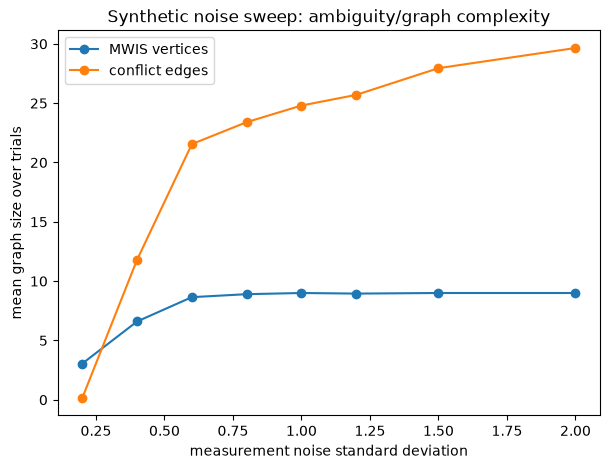

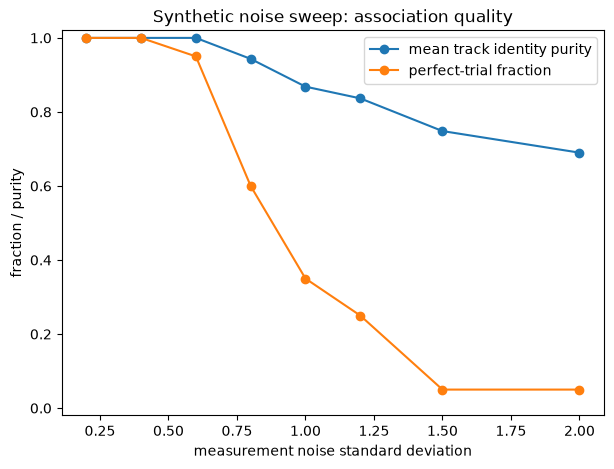

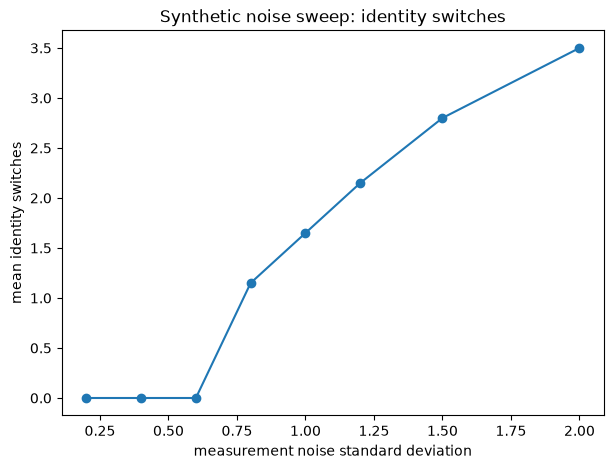

In [25]:
if RUN_NOISE_SWEEP:
    noise_raw, noise_summary = run_noise_sweep(n_trials=NOISE_SWEEP_TRIALS)

    print("Noise-sweep summary matrix:")
    noise_matrix = noise_summary.set_index("measurement_std")[
        [
            "graph_nodes_mean",
            "graph_edges_mean",
            "largest_component_mean",
            "purity_mean",
            "switches_mean",
            "perfect_trial_rate",
        ]
    ]
    display(noise_matrix.round(3))
    plot_noise_sweep(noise_summary)
else:
    noise_raw = noise_summary = None
    print("Noise sweep disabled.")

## Optional: slightly larger synthetic stress case

In [26]:
RUN_SYNTHETIC_STRESS = False

if RUN_SYNTHETIC_STRESS:
    stress_cfg = dict(
        n_targets=4,
        n_frames=4,
        dt=1.0,
        measurement_std=0.65,
        p_detection=0.98,
        clutter_rate=0.8,
        seed=11,
    )
    stress_scans, stress_truth = generate_synthetic_scans(**stress_cfg)
    stress_mht_cfg = dict(
        dt=1.0,
        process_std=0.50,
        measurement_std=stress_cfg["measurement_std"],
        p_detection=stress_cfg["p_detection"],
        beta_fa=1e-3,
        gate_threshold=9.21,
        top_k_per_family=2,
        max_consecutive_misses=1,
        enforce_class_consistency=False,
    )
    stress_hypotheses = build_candidate_hypotheses(stress_scans, **stress_mht_cfg)
    stress_G = build_conflict_graph(stress_hypotheses, positive_only=True)

    print("Stress graph nodes:", stress_G.number_of_nodes())
    print("Stress graph edges:", stress_G.number_of_edges())
    print("Stress components:", sorted([len(c) for c in nx.connected_components(stress_G)], reverse=True))
    plot_scans(stress_scans, stress_truth, "Synthetic stress case")
    draw_conflict_graph(stress_G, "Synthetic stress conflict graph")

    stress_classical_set, stress_classical_w, _ = solve_graph_classically(stress_G)
    print("Stress exact classical weight:", stress_classical_w)

    if RUN_QUANTUM and PULSER_AVAILABLE:
        stress_hybrid = solve_graph_hybrid(stress_G, max_quantum_nodes=MAX_QUANTUM_NODES)
        print("Stress hybrid final weight:", stress_hybrid["weight"])
        display(stress_hybrid["components"])
        display(quantum_component_summary(stress_hybrid))

# Part VI — Experiment B: RADIATE `tiny_foggy`

RADIATE is a multi-sensor automotive dataset. For this experiment we use only:

```text
tiny_foggy/
├── annotations/
│   └── annotations.json          # object ID, class, frame-wise rotated boxes
└── Navtech_Cartesian/
    ├── ....png                   # Cartesian radar images, when available locally
    └── ....png
```

The radar images are used here for **visualization**. Tracking uses the centre of each annotated vehicle bounding box:

$$
(x,y,w,h)\rightarrow(x_c,y_c)
=\left(x+\frac w2,y+\frac h2\right).
$$

The Cartesian radar representation is treated as 1152×1152 with an approximate scale of 0.17361 m/pixel, placing the radar at the image centre for the metric conversion used in this proof-of-concept. Annotation IDs are hidden from the tracker and retained only as `gt_id` for evaluation.

**Synchronization safeguard in v2.2.** The annotation sequence can contain more frame entries than the number of `Navtech_Cartesian` PNGs present in a local sample. The notebook therefore checks both counts and, when PNGs are present, restricts automatic window selection to frames that have a corresponding locally available PNG. The visualization assumes the sorted PNG list is sequentially aligned with annotation frame indices within that overlapping range; this assumption is printed explicitly as a diagnostic.


## 15. RADIATE loaders and radar-image visualization

In [27]:
RADIATE_CARTESIAN_SIZE = 1152
RADIATE_METRES_PER_PIXEL = 0.17361
RADIATE_VEHICLE_CLASSES = {
    "car", "van", "truck", "bus", "motorbike", "bicycle"
}


def bbox_center(position):
    x, y, w, h = map(float, position)
    return np.array([x + w / 2.0, y + h / 2.0], dtype=float)


def pixel_to_radar_metres(center_px):
    """Approximate radar-centred Cartesian (x,y) from the 1152x1152 image."""
    cx, cy = map(float, center_px)
    half = RADIATE_CARTESIAN_SIZE / 2.0
    return np.array([
        (cx - half) * RADIATE_METRES_PER_PIXEL,
        (half - cy) * RADIATE_METRES_PER_PIXEL,
    ])


def load_radiate_objects(sequence_path):
    sequence_path = Path(sequence_path)
    annotation_path = sequence_path / "annotations" / "annotations.json"
    if not annotation_path.exists():
        raise FileNotFoundError(
            f"Could not find {annotation_path}. Point RADIATE_SEQUENCE_PATH to tiny_foggy."
        )
    with annotation_path.open("r") as f:
        objects = json.load(f)
    if not isinstance(objects, list):
        raise ValueError("Expected annotations.json to contain a list of tracked objects.")
    return objects


def list_radiate_cartesian_images(sequence_path):
    """Return locally available Cartesian radar PNGs in filename order."""
    folder = Path(sequence_path) / "Navtech_Cartesian"
    if not folder.exists():
        return []
    return sorted(folder.glob("*.png"))


def radiate_availability_report(sequence_path, objects):
    """Summarize annotation-frame and local radar-PNG availability."""
    image_files = list_radiate_cartesian_images(sequence_path)
    annotation_frames = max((len(obj.get("bboxes", [])) for obj in objects), default=0)
    image_frames = len(image_files)
    overlap_frames = min(annotation_frames, image_frames) if image_frames else 0

    print("RADIATE data availability")
    print("-------------------------")
    print("Sequence:", Path(sequence_path))
    print("Annotation-frame entries:", annotation_frames)
    print("Local Navtech_Cartesian PNGs:", image_frames)

    if image_files:
        print("First PNG:", image_files[0].name)
        print("Last PNG:", image_files[-1].name)
        print("Sequential annotation/PNG overlap:", f"frames 0-{overlap_frames - 1}")
        print(
            "Indexing assumption: sorted PNG position i is used for annotation frame i "
            "inside the overlapping range."
        )
        if annotation_frames > image_frames:
            print(
                "WARNING: annotations extend beyond the locally available radar PNGs. "
                "Automatic window selection will be restricted to the image-supported overlap."
            )
    else:
        print(
            "WARNING: no Cartesian radar PNGs were found. Tracking can still use annotations, "
            "but raw radar-image visualization will be skipped."
        )

    return {
        "annotation_frames": annotation_frames,
        "image_frames": image_frames,
        "overlap_frames": overlap_frames,
        "image_files": image_files,
    }


def rotated_box_corners(position, rotation_deg):
    """Corners for plotting RADIATE's rotated rectangle on image coordinates."""
    x, y, w, h = map(float, position)
    center = np.array([x + w / 2.0, y + h / 2.0])
    corners = np.array([
        [-w/2, -h/2],
        [ w/2, -h/2],
        [ w/2,  h/2],
        [-w/2,  h/2],
    ])
    # Image y increases downwards, hence the sign flip for a mathematical rotation.
    theta = np.deg2rad(-float(rotation_deg))
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return corners @ R.T + center


def frame_annotations(objects, absolute_frame, classes=RADIATE_VEHICLE_CLASSES):
    rows = []
    if absolute_frame < 0:
        return rows

    for obj in objects:
        cls = obj.get("class_name", "unknown")
        if classes is not None and cls not in classes:
            continue
        bboxes = obj.get("bboxes", [])
        if absolute_frame >= len(bboxes) or not bboxes[absolute_frame]:
            continue
        bb = bboxes[absolute_frame]
        pos = bb.get("position") if isinstance(bb, dict) else None
        if pos is None:
            continue
        center_px = bbox_center(pos)
        rows.append({
            "id": obj.get("id"),
            "class_name": cls,
            "bbox": bb,
            "center_px": center_px,
            "center_m": pixel_to_radar_metres(center_px),
        })
    return rows


def plot_radiate_frame_image(
    sequence_path,
    objects,
    absolute_frame,
    kept_scan=None,
    selected_keys=None,
    show_ground_truth_ids=False,
):
    """Plot a Cartesian radar PNG and overlay annotations/detections when available."""
    image_files = list_radiate_cartesian_images(sequence_path)
    if not image_files:
        print("Navtech_Cartesian images not found; radar-image visualization skipped.")
        return

    if absolute_frame < 0 or absolute_frame >= len(image_files):
        print(
            f"Cannot visualize annotation frame {absolute_frame}: only {len(image_files)} "
            f"Cartesian radar PNGs are available locally (valid sequential indices "
            f"0-{len(image_files)-1})."
        )
        return

    img_path = image_files[absolute_frame]
    img = mpimg.imread(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray", origin="upper")

    # All vehicle annotations in the frame: bounding boxes only.
    for ann in frame_annotations(objects, absolute_frame):
        bb = ann["bbox"]
        corners = rotated_box_corners(bb["position"], bb.get("rotation", 0.0))
        plt.gca().add_patch(
            Polygon(corners, closed=True, fill=False, linewidth=1.0, alpha=0.5)
        )
        if show_ground_truth_ids:
            c = ann["center_px"]
            plt.text(c[0], c[1], f"{ann['class_name']} id={ann['id']}", fontsize=7)

    # Detections actually kept for MHT are shown with local identity-free IDs.
    if kept_scan is not None:
        selected_keys = set() if selected_keys is None else set(selected_keys)
        for det in kept_scan:
            c = det.meta["center_px"]
            marker = "*" if det.key in selected_keys else "o"
            size = 130 if det.key in selected_keys else 55
            plt.scatter([c[0]], [c[1]], marker=marker, s=size)
            plt.text(c[0], c[1], f"  det {det.local_id}", fontsize=8)

    plt.title(
        f"RADIATE Cartesian radar image\n"
        f"annotation frame {absolute_frame}, image {img_path.name}"
    )
    plt.xlim(0, img.shape[1])
    plt.ylim(img.shape[0], 0)
    plt.xlabel("image x [pixels]")
    plt.ylabel("image y [pixels]")
    plt.show()


## 16. Selecting a small RADIATE window without using ground-truth IDs

The window score uses only detection counts and geometry. In v2.2, `stop_search` is treated as an **exclusive** upper frame bound. When radar PNGs are present, the configuration cell sets this bound to the number of locally available images so that every selected annotation frame can also be visualized.


In [28]:
def radiate_frame_statistics(objects, classes=None, max_range_m=70.0, crowd_distance_m=15.0):
    n_frames = max(len(obj.get("bboxes", [])) for obj in objects)
    rows = []

    for k in range(n_frames):
        anns = frame_annotations(objects, k, classes=classes)
        pts = np.array([a["center_m"] for a in anns if np.linalg.norm(a["center_m"]) <= max_range_m])
        count = len(pts)
        if count >= 2:
            distances = pdist(pts)
            close_pairs = int(np.sum(distances <= crowd_distance_m))
            crowding = float(np.sum(np.exp(-distances / crowd_distance_m)))
        else:
            close_pairs = 0
            crowding = 0.0
        rows.append({"frame": k, "count": count, "close_pairs": close_pairs, "crowding": crowding})

    return pd.DataFrame(rows)


def choose_radiate_window(
    objects,
    n_frames=4,
    classes=RADIATE_VEHICLE_CLASSES,
    mode="busy",
    max_range_m=70.0,
    start_search=0,
    stop_search=None,
):
    """Choose a short window using positions/counts only, never annotation identities.

    `stop_search` is an exclusive upper frame bound. For example, if 18 local radar
    PNGs are available and n_frames=4, start frames 0..14 are eligible, so the final
    selected window can end at frame 17 but never request frame 18 or above.
    """
    stats = radiate_frame_statistics(objects, classes=classes, max_range_m=max_range_m)

    if n_frames < 1:
        raise ValueError("n_frames must be at least 1.")

    start_search = max(0, int(start_search))
    if stop_search is None:
        stop_search = len(stats)
    stop_search = min(int(stop_search), len(stats))

    last_start_exclusive = stop_search - n_frames + 1
    if last_start_exclusive <= start_search:
        raise ValueError(
            f"Not enough overlapping frames for a {n_frames}-frame RADIATE window: "
            f"search interval is [{start_search}, {stop_search})."
        )

    best = None
    for start in range(start_search, last_start_exclusive):
        window = stats.iloc[start:start+n_frames]
        if len(window) < n_frames or window.iloc[0]["count"] == 0:
            continue

        if mode == "crowded":
            score = (
                window["close_pairs"].sum(),
                window["crowding"].sum(),
                window["count"].min(),
                window["count"].sum(),
            )
        elif mode == "busy":
            score = (
                window["count"].min(),
                window["count"].mean(),
                window["count"].sum(),
                window["close_pairs"].sum(),
            )
        else:
            raise ValueError("mode must be 'busy' or 'crowded'.")

        if best is None or score > best[0]:
            best = (score, start, window.copy())

    if best is None:
        raise ValueError(
            f"Could not find a non-empty {n_frames}-frame RADIATE window "
            f"inside [{start_search}, {stop_search})."
        )
    return best[1], best[2], stats


def load_radiate_scans_from_annotations(
    sequence_path,
    start_frame,
    n_frames=4,
    frame_stride=1,
    classes=RADIATE_VEHICLE_CLASSES,
    use_metres=True,
    max_range_m=70.0,
    max_objects_per_frame=4,
):
    objects = load_radiate_objects(sequence_path)
    scans = []

    for local_frame in range(n_frames):
        absolute_frame = start_frame + local_frame * frame_stride
        dets = []

        for ann in frame_annotations(objects, absolute_frame, classes=classes):
            z = ann["center_m"] if use_metres else ann["center_px"]
            if use_metres and np.linalg.norm(z) > max_range_m:
                continue

            dets.append(
                Detection(
                    frame=local_frame,
                    local_id=-1,
                    z=np.asarray(z, float),
                    gt_id=str(ann["id"]) if ann["id"] is not None else None,
                    meta={
                        "class_name": ann["class_name"],
                        "bbox": ann["bbox"],
                        "absolute_frame": absolute_frame,
                        "center_px": ann["center_px"],
                    },
                )
            )

        # Complexity control uses distance to the radar, not ground-truth identity.
        dets.sort(key=lambda d: np.linalg.norm(d.z))
        if max_objects_per_frame is not None:
            dets = dets[:max_objects_per_frame]
        for j, det in enumerate(dets):
            det.local_id = j
        scans.append(dets)

    return scans


## 17. RADIATE configuration, synchronization diagnostic, raw image visualization, and extracted detections

This cell now prints annotation/image counts before selecting the experiment window. If radar PNGs exist, the search is restricted to the overlapping sequential frame range, eliminating the earlier `Frame index ... exceeds ... radar images` warnings for the selected window.


RADIATE data availability
-------------------------
Sequence: /Users/sqgh94@durham.ac.uk/Downloads/NBQSS/v2/tiny_foggy
Annotation-frame entries: 714
Local Navtech_Cartesian PNGs: 18
First PNG: 000001.png
Last PNG: 000018.png
Sequential annotation/PNG overlap: frames 0-17
Indexing assumption: sorted PNG position i is used for annotation frame i inside the overlapping range.

RADIATE experiment selection
----------------------------
RADIATE path: /Users/sqgh94@durham.ac.uk/Downloads/NBQSS/v2/tiny_foggy
Profile: baseline
Window mode: busy
Chosen start frame: 10
Chosen annotation frames: [10, 11, 12, 13]


,frame,count,close_pairs,crowding
10,10,3,0,0.405498
11,11,3,0,0.363086
12,12,3,0,0.332892
13,13,3,0,0.316947


Detections actually kept per frame: [3, 3, 3, 3]


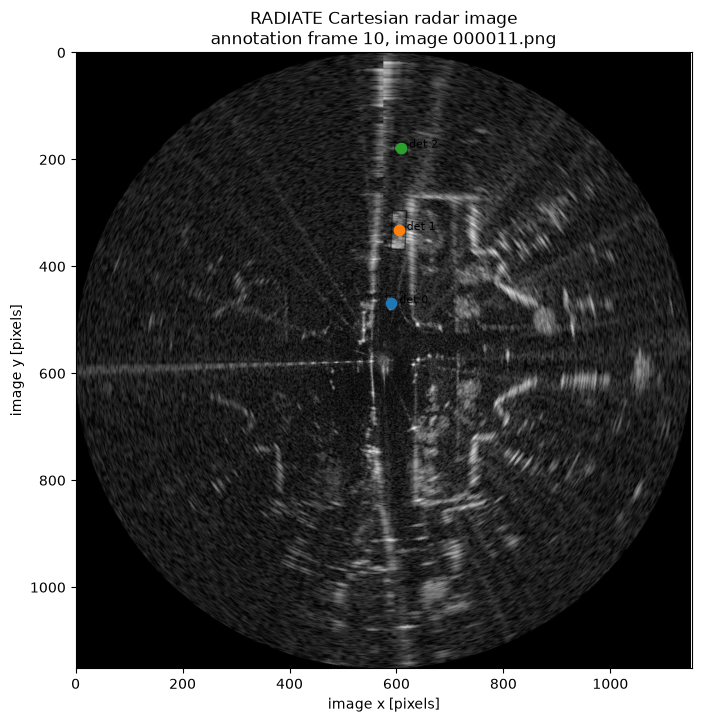

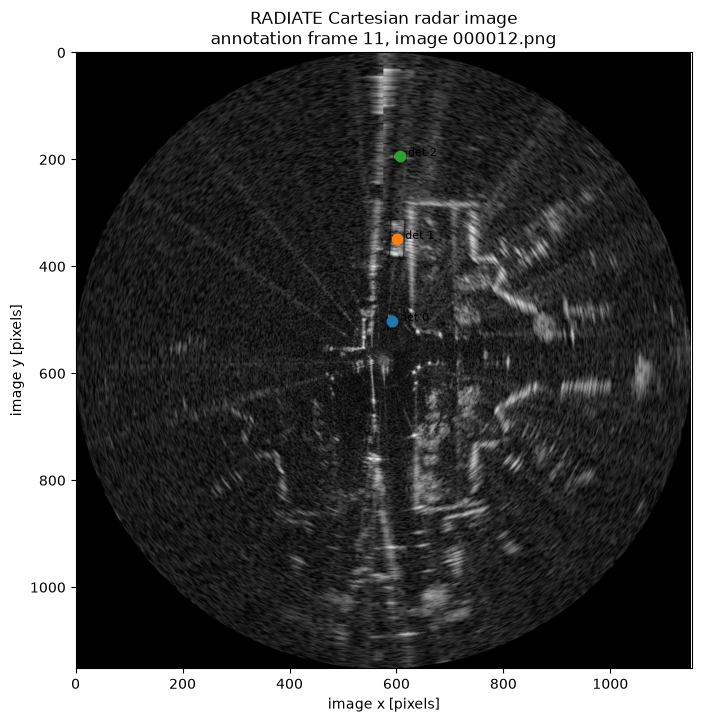

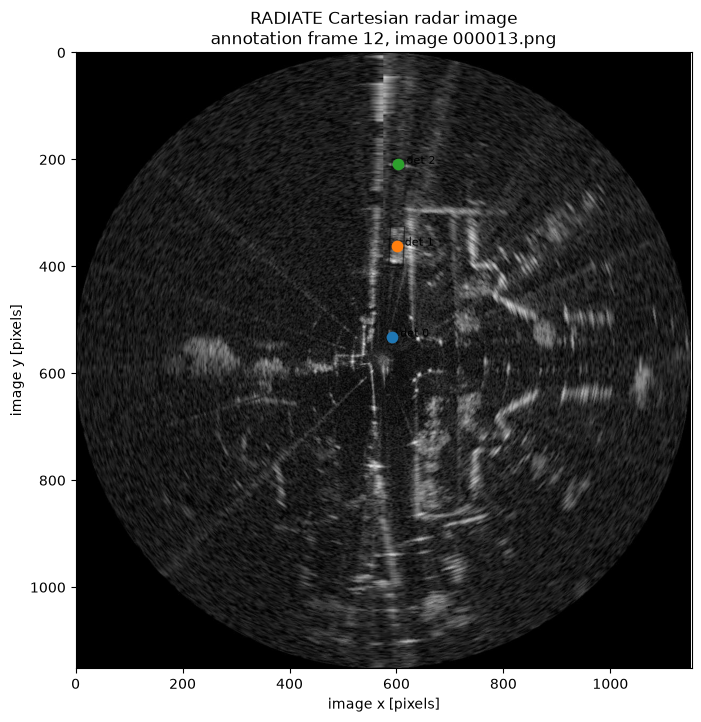

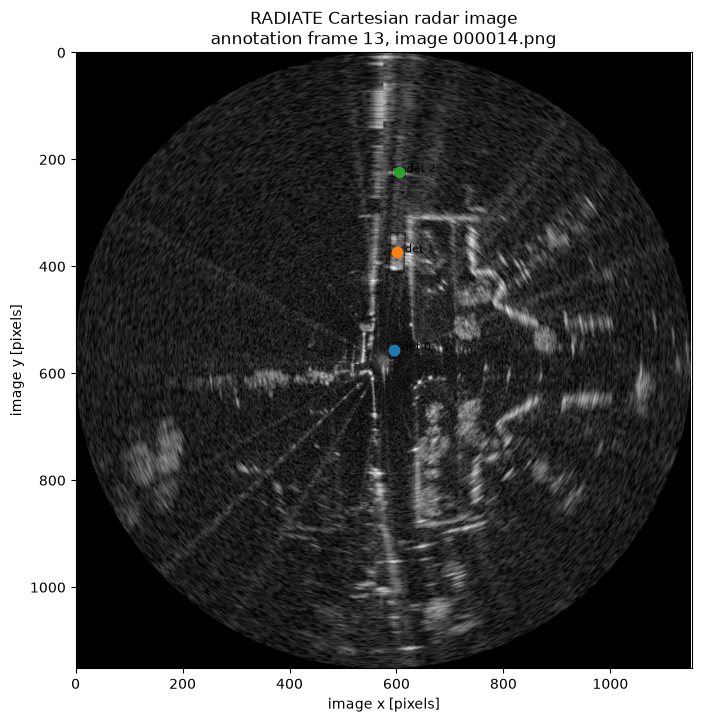

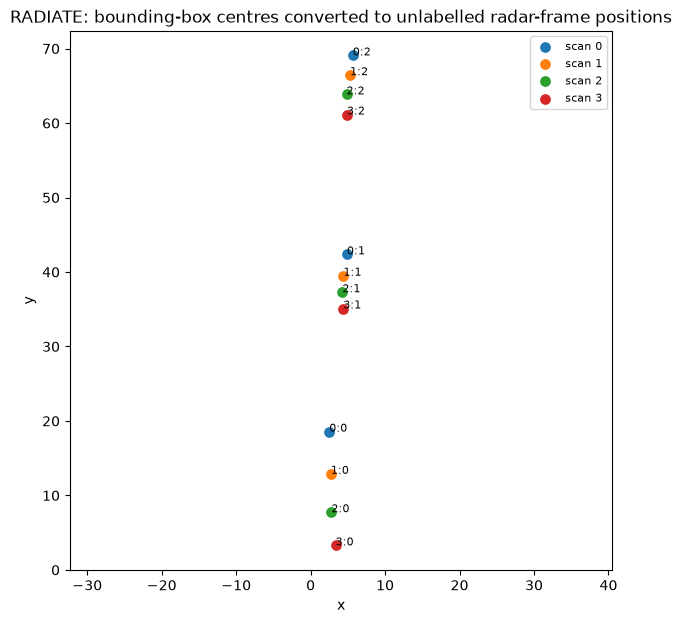

In [29]:
if RADIATE_PROFILE == "stress":
    RADIATE_N_FRAMES = 5
    RADIATE_MAX_OBJECTS_PER_FRAME = 5
    RADIATE_TOP_K_PER_FAMILY = 3
else:
    RADIATE_N_FRAMES = 4
    RADIATE_MAX_OBJECTS_PER_FRAME = 4
    RADIATE_TOP_K_PER_FAMILY = 2

RADIATE_DT = 0.25  # 4 Hz radar

radiate_objects = None
radiate_scans = None
radiate_G = None
radiate_start_frame = None
radiate_availability = None

if RADIATE_SEQUENCE_PATH.exists():
    radiate_objects = load_radiate_objects(RADIATE_SEQUENCE_PATH)

    # First diagnose how many annotation frames and radar images are actually present.
    radiate_availability = radiate_availability_report(
        RADIATE_SEQUENCE_PATH,
        radiate_objects,
    )
    radiate_image_files = radiate_availability["image_files"]

    # If images exist, restrict the automatic annotation-window search to the
    # overlapping frame range so every selected frame can be shown as a radar PNG.
    # If no images exist, keep the tracking experiment available from annotations.
    if radiate_image_files:
        if len(radiate_image_files) < RADIATE_N_FRAMES:
            raise ValueError(
                f"Only {len(radiate_image_files)} radar PNGs are available, but the "
                f"selected profile requires {RADIATE_N_FRAMES} consecutive frames."
            )
        radiate_stop_search = len(radiate_image_files)
    else:
        radiate_stop_search = None

    radiate_start_frame, chosen_window_stats, radiate_frame_stats = choose_radiate_window(
        radiate_objects,
        n_frames=RADIATE_N_FRAMES,
        classes=RADIATE_VEHICLE_CLASSES,
        mode=RADIATE_WINDOW_MODE,
        max_range_m=70.0,
        start_search=0,
        stop_search=radiate_stop_search,
    )

    print("\nRADIATE experiment selection")
    print("----------------------------")
    print("RADIATE path:", RADIATE_SEQUENCE_PATH)
    print("Profile:", RADIATE_PROFILE)
    print("Window mode:", RADIATE_WINDOW_MODE)
    print("Chosen start frame:", radiate_start_frame)
    print(
        "Chosen annotation frames:",
        list(range(radiate_start_frame, radiate_start_frame + RADIATE_N_FRAMES)),
    )
    display(chosen_window_stats)

    radiate_scans = load_radiate_scans_from_annotations(
        RADIATE_SEQUENCE_PATH,
        start_frame=radiate_start_frame,
        n_frames=RADIATE_N_FRAMES,
        classes=RADIATE_VEHICLE_CLASSES,
        use_metres=True,
        max_range_m=70.0,
        max_objects_per_frame=RADIATE_MAX_OBJECTS_PER_FRAME,
    )
    print("Detections actually kept per frame:", [len(s) for s in radiate_scans])

    # Visualize the ACTUAL radar PNGs when they are locally available.
    # IDs remain hidden; only local detection IDs are shown to mirror tracker input.
    if radiate_image_files:
        for local_frame, scan in enumerate(radiate_scans):
            absolute_frame = radiate_start_frame + local_frame
            plot_radiate_frame_image(
                RADIATE_SEQUENCE_PATH,
                radiate_objects,
                absolute_frame,
                kept_scan=scan,
                show_ground_truth_ids=False,
            )
    else:
        print("Raw radar-image visualization skipped because no PNGs are available.")

    # The point representation that is actually passed to MHT.
    plot_scans(
        radiate_scans,
        truths=None,
        title="RADIATE: bounding-box centres converted to unlabelled radar-frame positions",
    )
else:
    print("RADIATE sample not found at:", RADIATE_SEQUENCE_PATH)
    print("Edit RADIATE_SEQUENCE_PATH, then re-run this cell and the RADIATE cells below.")


### B1. RADIATE filtering/gating visualization

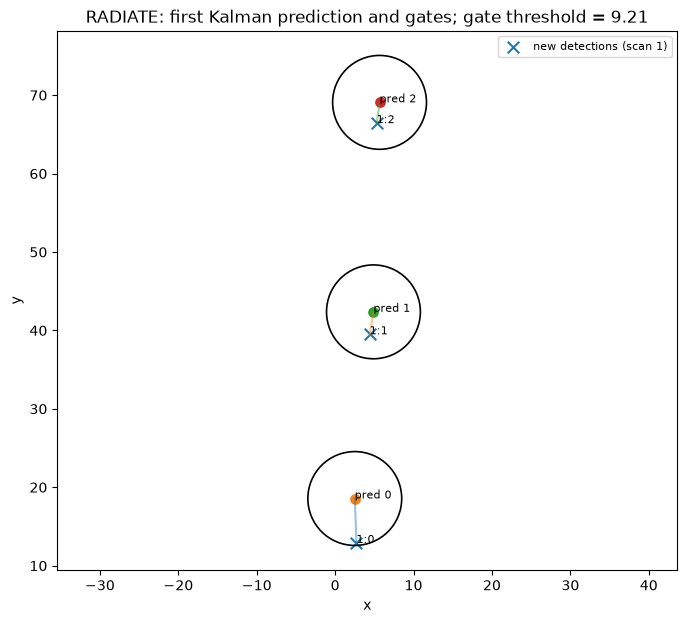

In [30]:
RADIATE_MHT_CFG = dict(
    dt=RADIATE_DT,
    process_std=3.0,
    measurement_std=1.2,
    p_detection=0.95,
    beta_fa=2e-4,
    gate_threshold=9.21,
    top_k_per_family=RADIATE_TOP_K_PER_FAMILY,
    max_consecutive_misses=1,
    enforce_class_consistency=False,
)

if radiate_scans is not None and radiate_scans[0]:
    visualize_first_gating_step(
        radiate_scans,
        dt=RADIATE_MHT_CFG["dt"],
        process_std=RADIATE_MHT_CFG["process_std"],
        measurement_std=RADIATE_MHT_CFG["measurement_std"],
        gate_threshold=RADIATE_MHT_CFG["gate_threshold"],
        title="RADIATE: first Kalman prediction and gates",
    )
else:
    print("RADIATE scans are not loaded yet.")

### B2. RADIATE candidate tracks and conflict graph

Final candidate hypotheses: 6
Positive-weight MWIS vertices: 5
Conflict edges: 2
Connected component sizes: [2, 2, 1]


,hid,family,LLR,history,GT ids (evaluation only)
0,19,1,13.592619,"[(0, 1), (1, 1), (2, 1), (3, 1)]","[1, 1, 1, 1]"
1,22,2,13.184107,"[(0, 2), (1, 2), (2, 2), (3, 2)]","[3, 3, 3, 3]"
2,17,0,5.840214,"[(0, 0), (1, 0), (2, 0), (3, 0)]","[2, 2, 2, 2]"
3,20,1,5.631127,"[(0, 1), (1, 1), (2, 1), None]","[1, 1, 1]"
4,23,2,5.532618,"[(0, 2), (1, 2), (2, 2), None]","[3, 3, 3]"
5,18,0,-0.885414,"[(0, 0), (1, 0), (2, 0), None]","[2, 2, 2]"


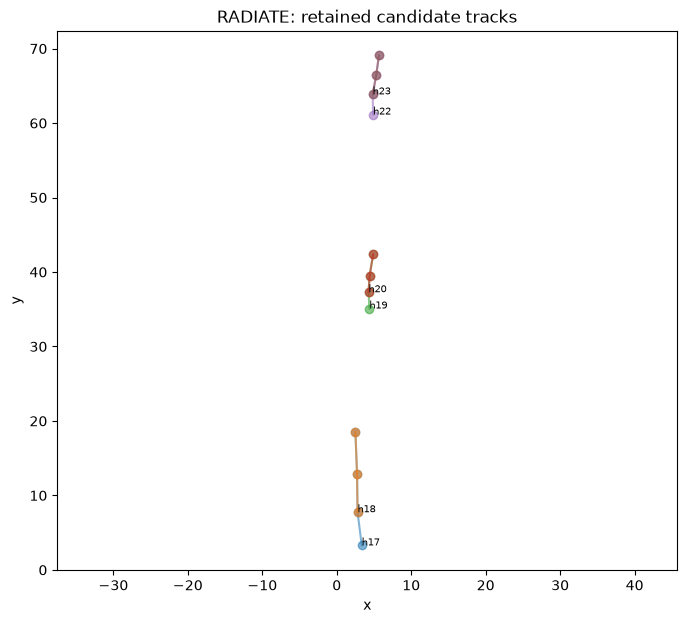

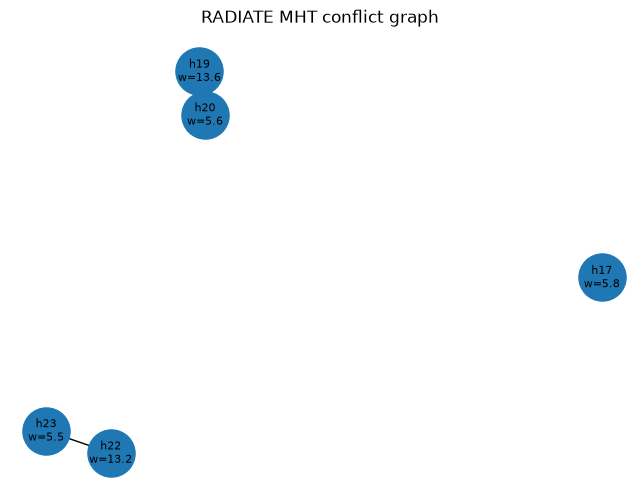

In [31]:
if radiate_scans is not None and radiate_scans[0]:
    radiate_hypotheses = build_candidate_hypotheses(radiate_scans, **RADIATE_MHT_CFG)
    radiate_G = build_conflict_graph(radiate_hypotheses, positive_only=True)

    print("Final candidate hypotheses:", len(radiate_hypotheses))
    print("Positive-weight MWIS vertices:", radiate_G.number_of_nodes())
    print("Conflict edges:", radiate_G.number_of_edges())
    print("Connected component sizes:", sorted([len(c) for c in nx.connected_components(radiate_G)], reverse=True))

    display(hypothesis_table(radiate_hypotheses, limit=40))
    plot_candidate_tracks(radiate_hypotheses, "RADIATE: retained candidate tracks")
    draw_conflict_graph(radiate_G, "RADIATE MHT conflict graph")
else:
    radiate_hypotheses = None
    radiate_G = None
    print("RADIATE pipeline not run yet.")

### B3. Exact classical RADIATE solution and top-K hypotheses

Exact classical MWIS weight: 32.61694029034076


,component,nodes,edges,solver,selected,weight,runtime_s
0,0,1,0,exact MILP,[17],5.840214,0.000587
1,1,2,1,exact MILP,[19],13.592619,0.000404
2,2,2,1,exact MILP,[22],13.184107,0.000483


,vertex,family,weight,history,GT ids (evaluation only)
0,17,0,5.840214,"[(0, 0), (1, 0), (2, 0), (3, 0)]","[2, 2, 2, 2]"
1,19,1,13.592619,"[(0, 1), (1, 1), (2, 1), (3, 1)]","[1, 1, 1, 1]"
2,22,2,13.184107,"[(0, 2), (1, 2), (2, 2), (3, 2)]","[3, 3, 3, 3]"


,vertex,weight,n_labeled_detections,dominant_gt_id,identity_purity,identity_switches
0,17,5.840214,4,2,1.0,0
1,19,13.592619,4,1,1.0,0
2,22,13.184107,4,3,1.0,0


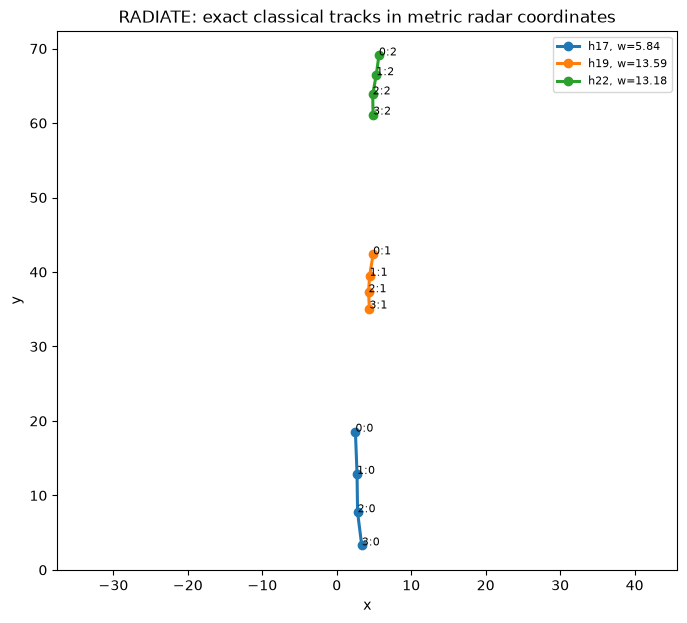

Top classical RADIATE global hypotheses:


,bitstring,selected,weight,relative_score_mass
0,11010,"{17, 19, 22}",32.616940,9.962760e-01
1,01010,"{19, 22}",26.776727,2.897391e-03
2,11001,"{17, 19, 23}",24.965451,4.735655e-04
3,10110,"{17, 20, 22}",24.655447,3.473339e-04
4,11000,"{17, 19}",19.432833,1.873245e-06
5,01001,"{19, 23}",19.125237,1.377233e-06
6,10010,"{17, 22}",19.024321,1.245031e-06
7,00110,"{20, 22}",18.815234,1.010124e-06
8,10101,"{17, 20, 23}",17.003958,1.651002e-07
9,01000,{19},13.592619,5.447812e-09


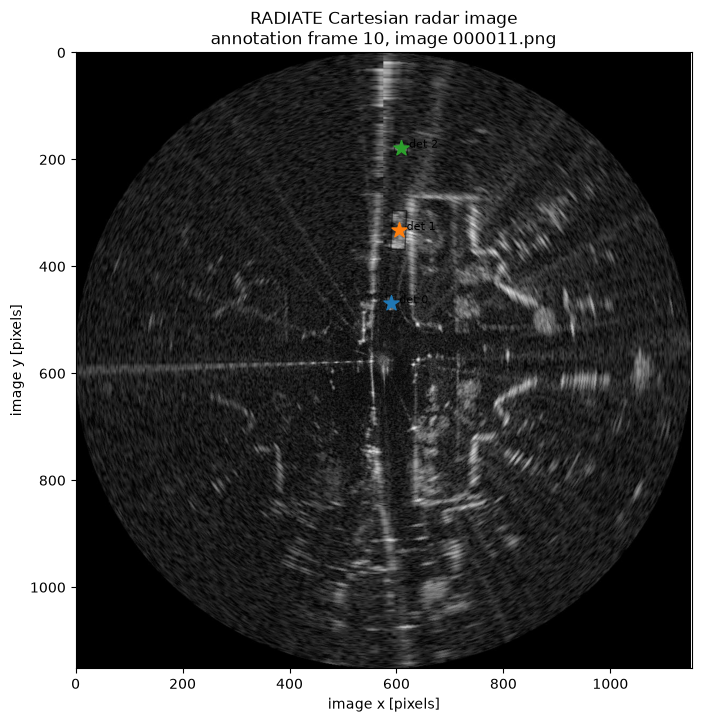

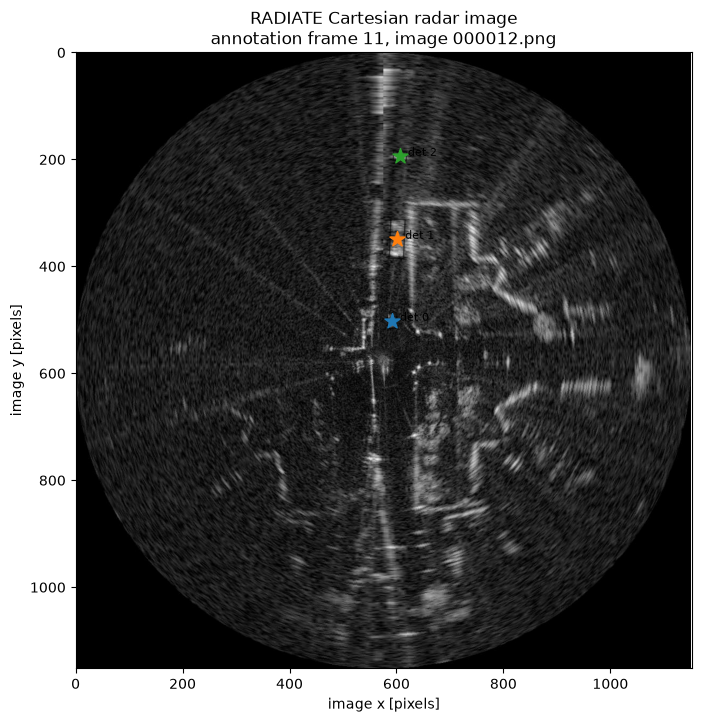

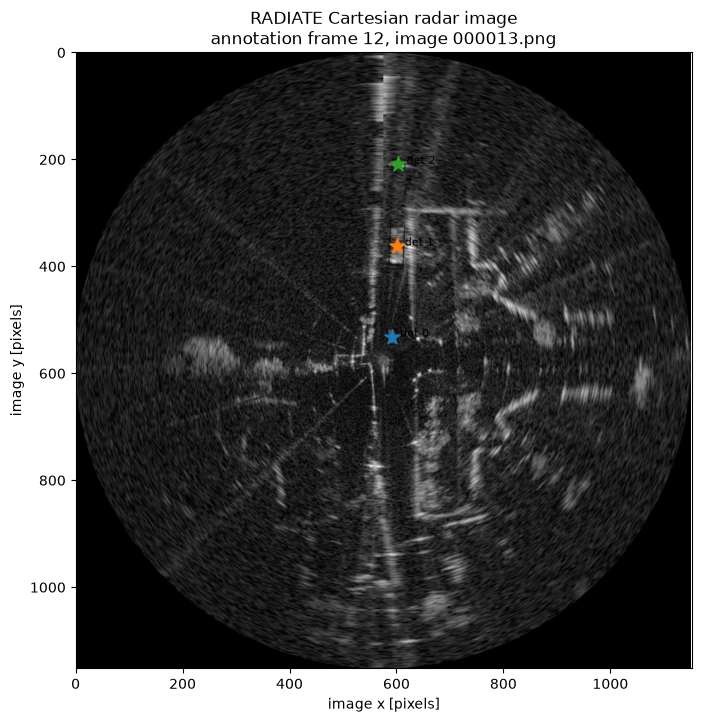

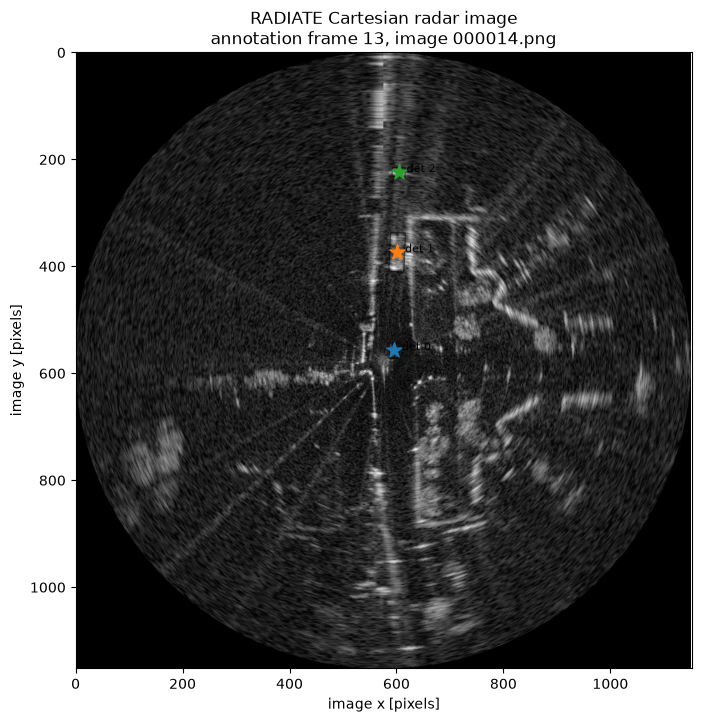

In [32]:
if radiate_G is not None and len(radiate_G):
    radiate_classical_set, radiate_classical_w, radiate_classical_components = solve_graph_classically(radiate_G)
    print("Exact classical MWIS weight:", radiate_classical_w)
    display(radiate_classical_components)
    display(selected_hypothesis_table(radiate_G, radiate_classical_set))
    display(identity_metrics(radiate_G, radiate_classical_set))
    plot_selected_tracks(radiate_G, radiate_classical_set, "RADIATE: exact classical tracks in metric radar coordinates")

    print("Top classical RADIATE global hypotheses:")
    radiate_topk_classical = top_k_classical_hypotheses(radiate_G, k=10)
    display(radiate_topk_classical)

    # Show which detections selected by the exact global hypothesis lie on the actual radar images.
    selected_detection_keys = set()
    for n in radiate_classical_set:
        selected_detection_keys |= set(radiate_G.nodes[n]["hypothesis"].used_detection_keys)

    if radiate_objects is not None:
        for local_frame, scan in enumerate(radiate_scans):
            absolute_frame = radiate_start_frame + local_frame
            plot_radiate_frame_image(
                RADIATE_SEQUENCE_PATH,
                radiate_objects,
                absolute_frame,
                kept_scan=scan,
                selected_keys=selected_detection_keys,
                show_ground_truth_ids=False,
            )
else:
    radiate_classical_set, radiate_classical_w = None, None
    print("RADIATE graph unavailable.")

### B4. Hybrid RADIATE solution and atom/QC visualizations

Operational hybrid solution weight: 32.61694029034076
Ratio to exact classical: 1.0


,component,nodes,edges,solver,quantum_attempted,selected,weight,exact_component_weight
0,0,1,0,classical-trivial,False,[17],5.840214,5.840214
1,1,2,1,neutral-atom/Pulser,True,[19],13.592619,13.592619
2,2,2,1,neutral-atom/Pulser,True,[22],13.184107,13.184107


,vertex,family,weight,history,GT ids (evaluation only)
0,17,0,5.840214,"[(0, 0), (1, 0), (2, 0), (3, 0)]","[2, 2, 2, 2]"
1,19,1,13.592619,"[(0, 1), (1, 1), (2, 1), (3, 1)]","[1, 1, 1, 1]"
2,22,2,13.184107,"[(0, 2), (1, 2), (2, 2), (3, 2)]","[3, 3, 3, 3]"


,vertex,weight,n_labeled_detections,dominant_gt_id,identity_purity,identity_switches
0,17,5.840214,4,2,1.0,0
1,19,13.592619,4,1,1.0,0
2,22,13.184107,4,3,1.0,0


Raw quantum-component diagnostics:


,component,atoms,embedding_loss,normalized_embedding_loss,edge_nonedge_separation,feasible_probability,optimal_probability,chosen_bitstring,chosen_weight,exact_component_weight,runtime_s
0,1,2,1.401697e-08,9.911496e-09,inf,1.0,0.998,10,13.592619,13.592619,0.232124
1,2,2,1.401697e-08,9.911496e-09,inf,1.0,0.992,10,13.184107,13.184107,0.209743



RADIATE quantum component 1
Most-probable feasible bitstring: 10
Feasible probability mass: 1.0
Optimal probability mass: 0.998


,bitstring,probability,feasible,weight,selected
0,10,0.998,True,13.592619,{19}
1,01,0.002,True,5.631127,{20}


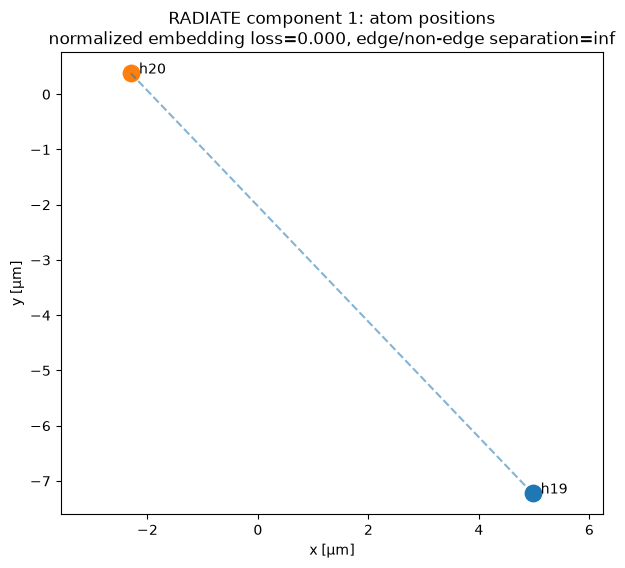

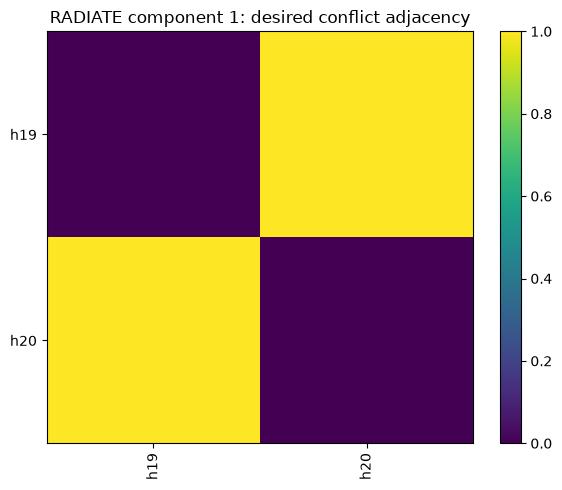

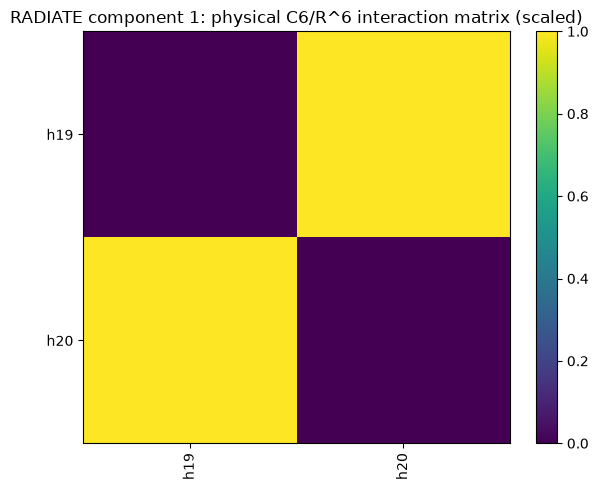

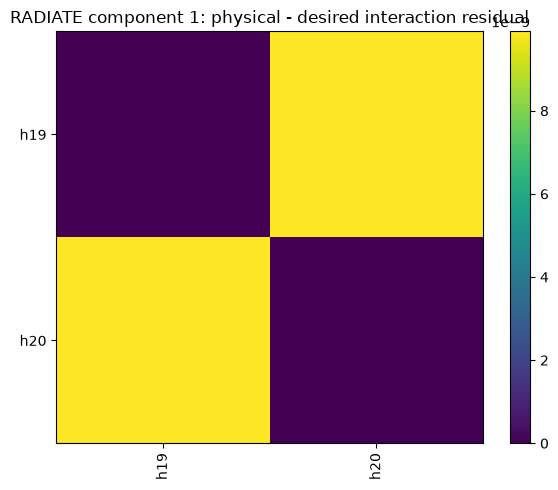

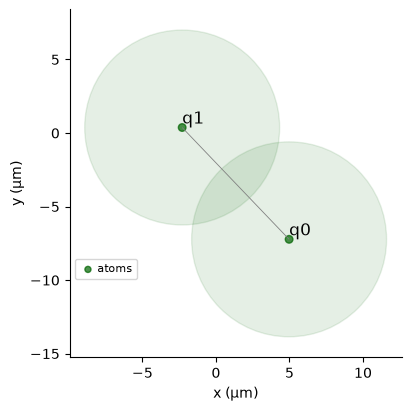

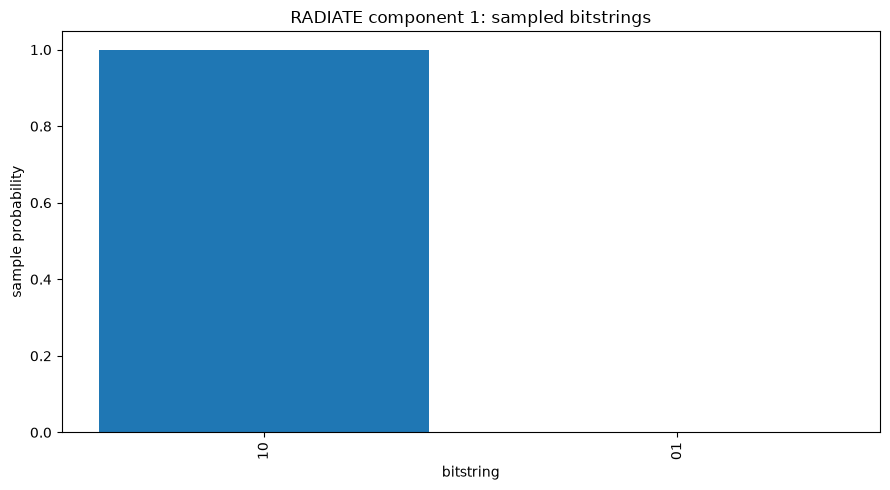

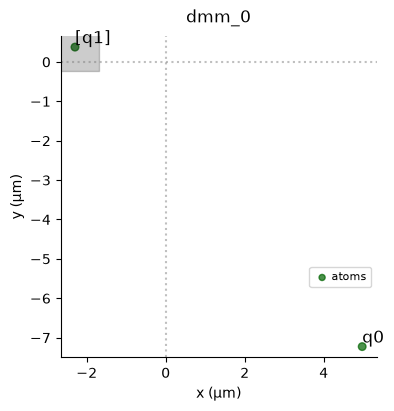

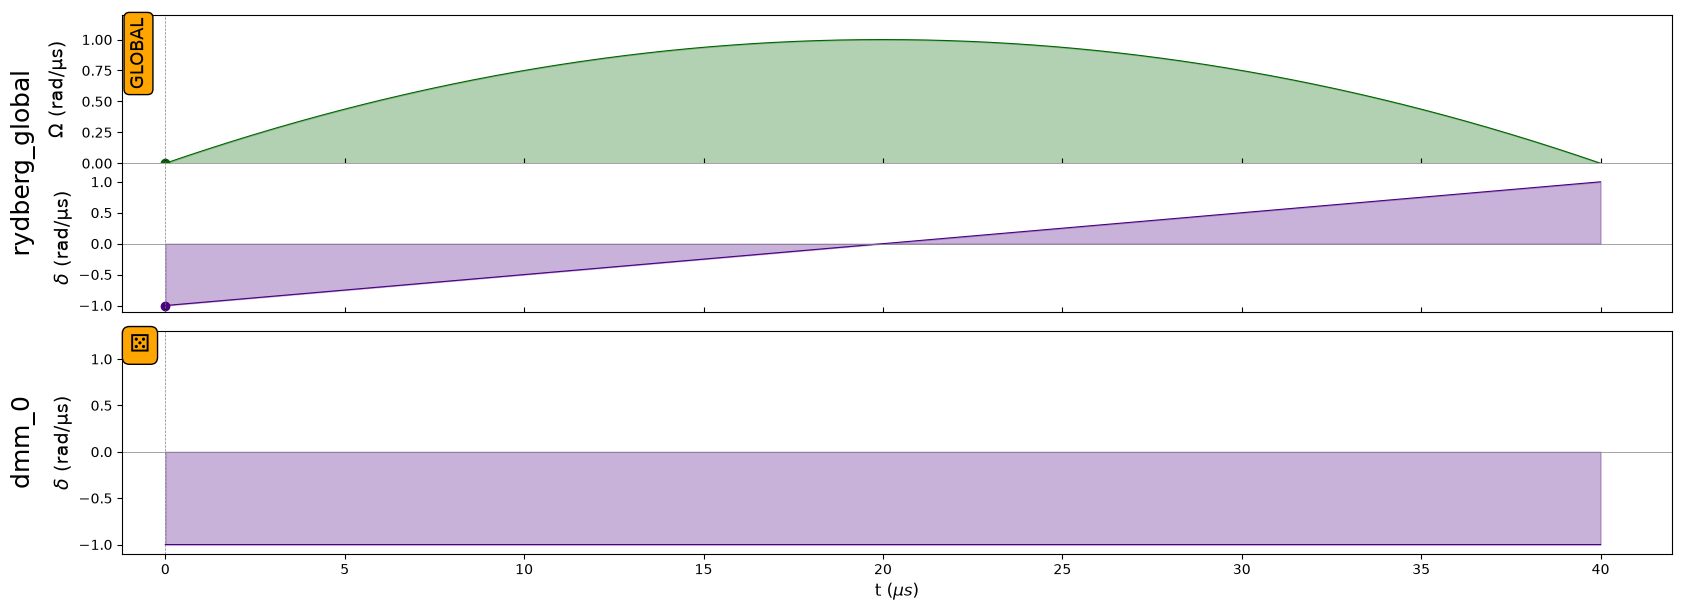

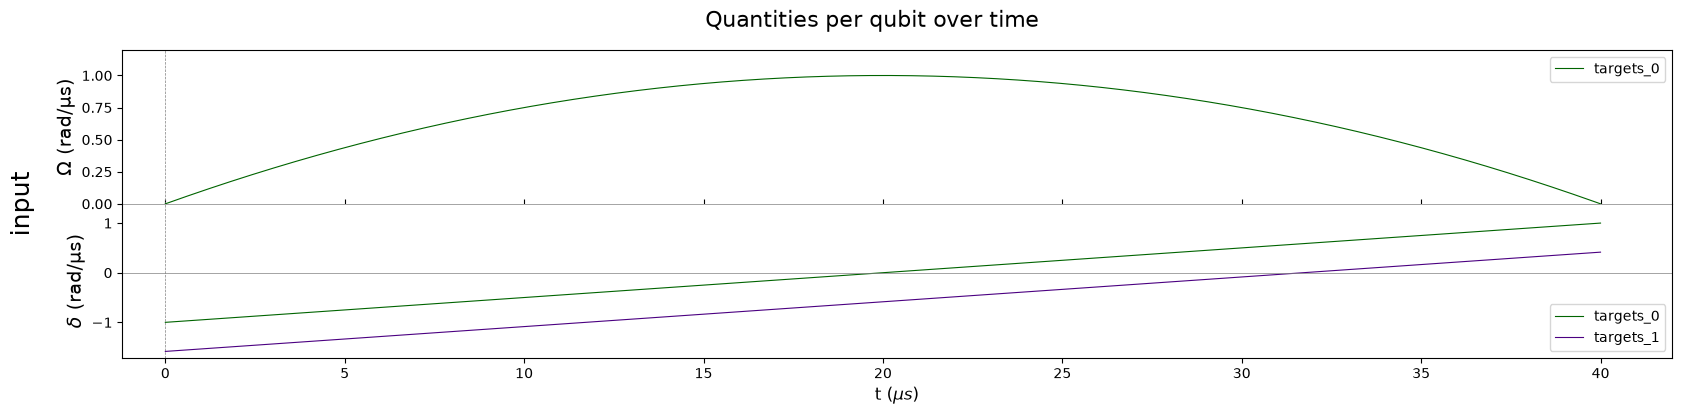

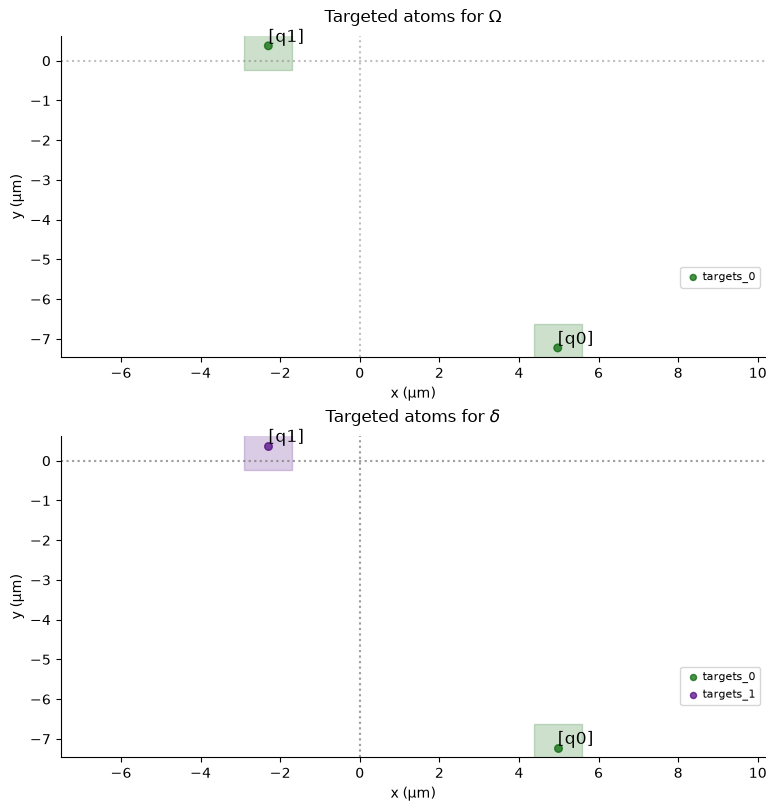


RADIATE quantum component 2
Most-probable feasible bitstring: 10
Feasible probability mass: 1.0
Optimal probability mass: 0.992


,bitstring,probability,feasible,weight,selected
0,10,0.992,True,13.184107,{22}
1,01,0.007,True,5.532618,{23}
2,00,0.001,True,0.000000,{}


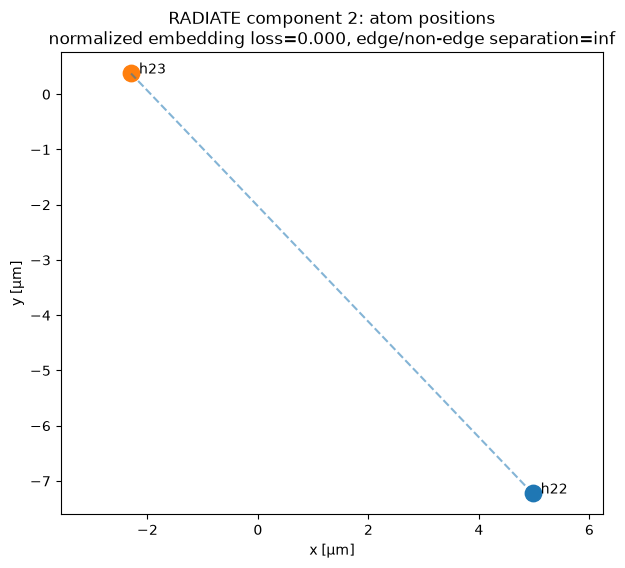

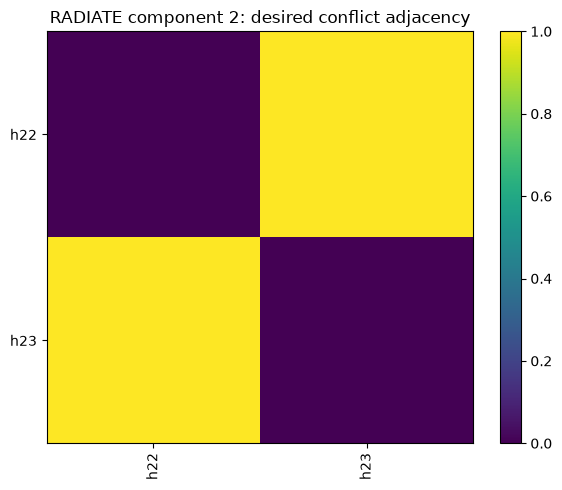

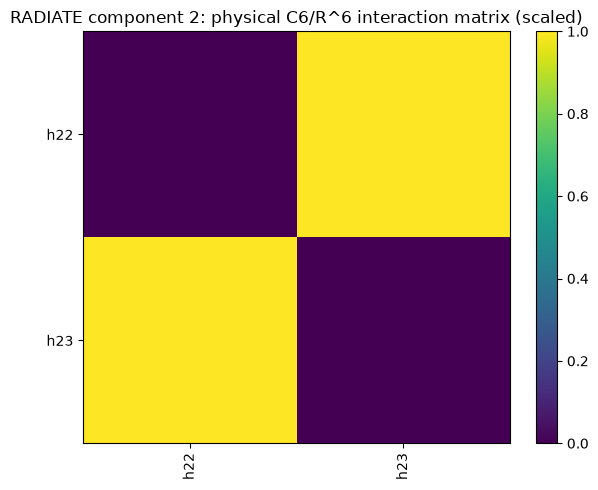

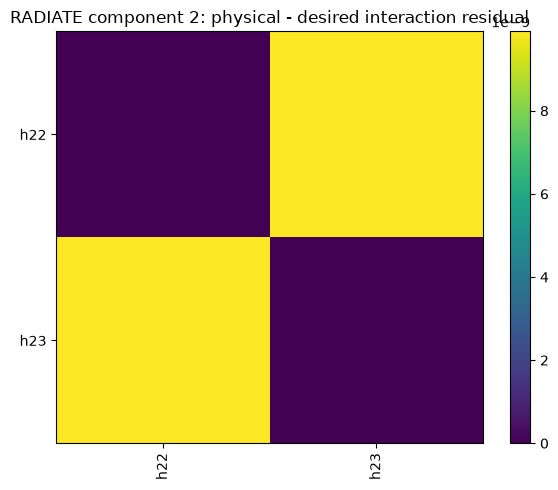

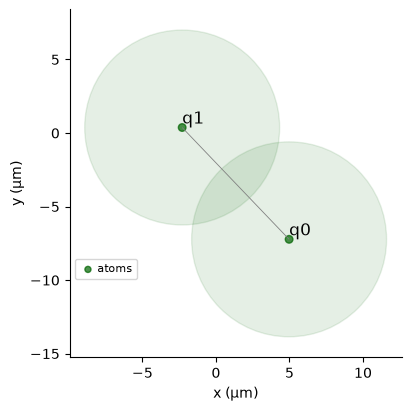

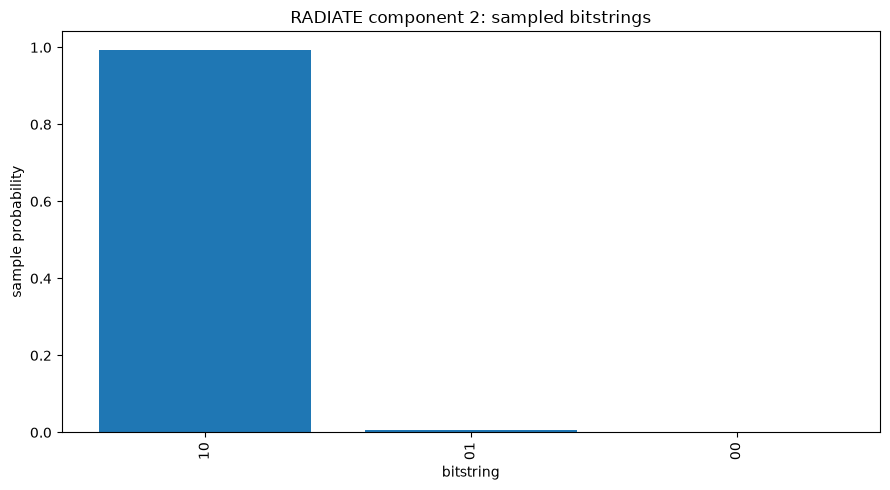

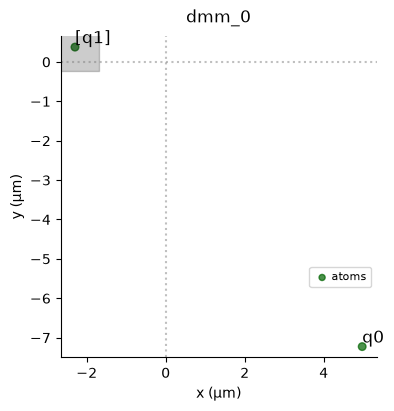

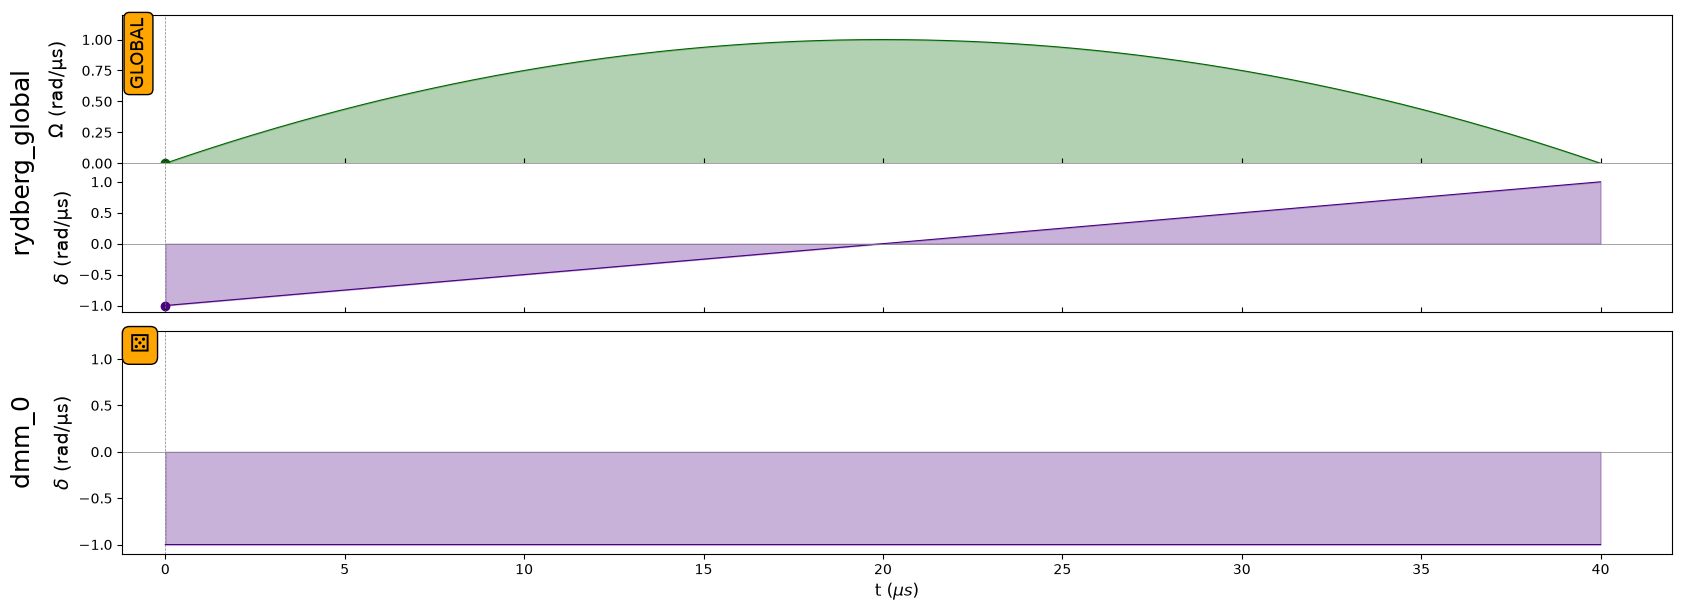

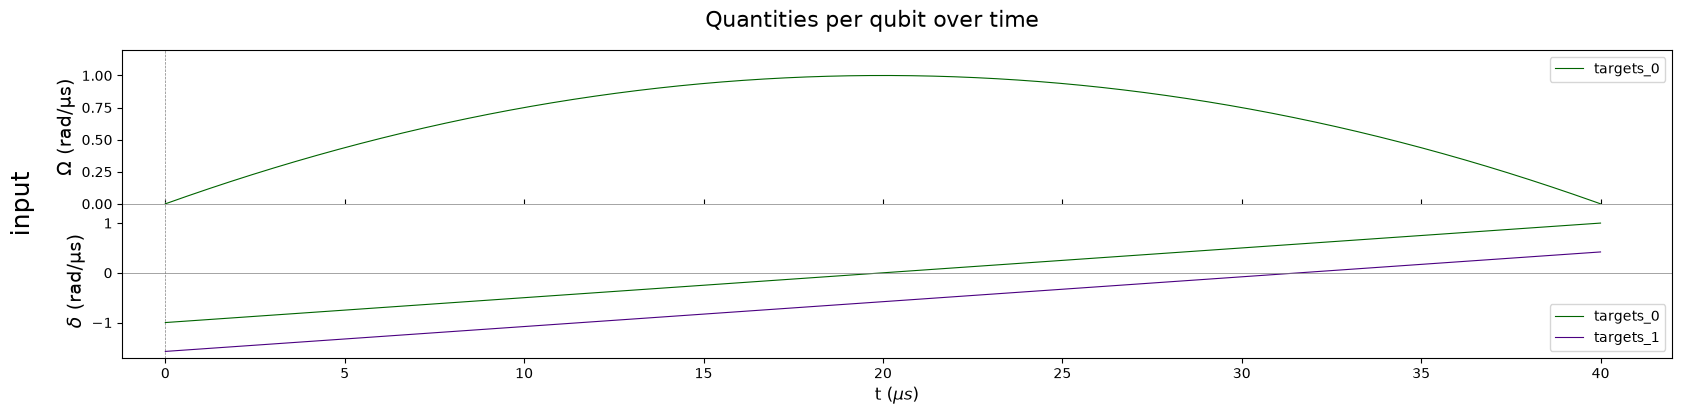

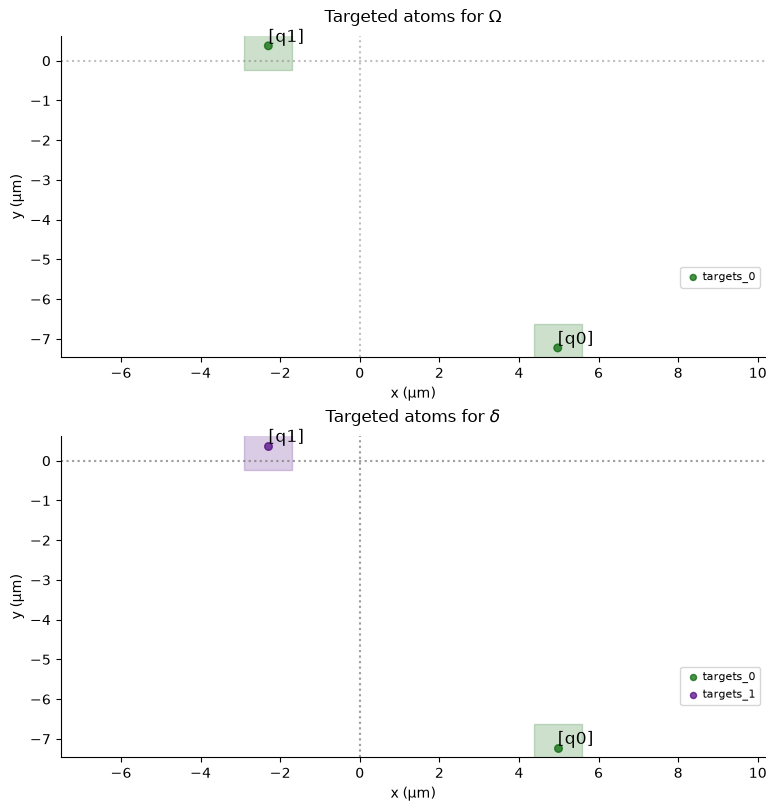

Top global hybrid/quantum RADIATE hypotheses:


,selected,probability,weight
0,"{17, 19, 22}",0.990016,32.616940
1,"{17, 19, 23}",0.006986,24.965451
2,"{17, 20, 22}",0.001984,24.655447
3,"{17, 19}",0.000998,19.432833
4,"{17, 20, 23}",0.000014,17.003958
5,"{17, 20}",0.000002,11.471340


In [33]:
if radiate_G is not None and len(radiate_G) and RUN_QUANTUM and PULSER_AVAILABLE:
    radiate_hybrid = solve_graph_hybrid(
        radiate_G,
        max_quantum_nodes=MAX_QUANTUM_NODES,
        duration_ns=QUANTUM_DURATION_NS,
        fallback_if_no_feasible=True,
    )

    print("Operational hybrid solution weight:", radiate_hybrid["weight"])
    print("Ratio to exact classical:", radiate_hybrid["weight"] / radiate_classical_w)
    display(radiate_hybrid["components"])
    display(selected_hypothesis_table(radiate_G, radiate_hybrid["selected"]))
    display(identity_metrics(radiate_G, radiate_hybrid["selected"]))

    print("Raw quantum-component diagnostics:")
    display(quantum_component_summary(radiate_hybrid))

    radiate_components = list(nx.connected_components(radiate_G))
    for cidx, detail in radiate_hybrid["quantum_details"].items():
        SG = radiate_G.subgraph(radiate_components[cidx]).copy()
        print(f"\nRADIATE quantum component {cidx}")
        print("Most-probable feasible bitstring:", detail["bitstring"])
        print("Feasible probability mass:", detail["feasible_probability"])
        print("Optimal probability mass:", detail.get("optimal_probability"))
        display(detail["distribution"].head(15))

        plot_embedding_diagnostics(detail["embedding"], SG, title_prefix=f"RADIATE component {cidx}")
        plot_quantum_distribution(detail, title=f"RADIATE component {cidx}: sampled bitstrings")

        try:
            detail["sequence"].draw(
                draw_detuning_maps=True,
                draw_qubit_det=True,
                draw_qubit_amp=True,
            )
            plt.show()
        except Exception as exc:
            print("Pulser sequence drawing skipped:", exc)

    print("Top global hybrid/quantum RADIATE hypotheses:")
    display(top_k_quantum_global_hypotheses(radiate_G, radiate_hybrid, k_global=10))
else:
    radiate_hybrid = None
    if radiate_G is None:
        print("RADIATE data are not loaded.")
    elif not PULSER_AVAILABLE:
        print("Pulser unavailable; hybrid RADIATE run skipped.")
    elif not RUN_QUANTUM:
        print("RUN_QUANTUM=False; hybrid RADIATE run skipped.")

# Part VII — Final 2 × 2 comparison matrix

In [34]:
summary_rows = []

summary_rows.append(
    summarize_solution(
        "Synthetic — exact classical MILP",
        synthetic_G,
        synthetic_classical_set,
        exact_weight=synthetic_classical_w,
    )
)

if synthetic_hybrid is not None:
    row = summarize_solution(
        "Synthetic — operational hybrid",
        synthetic_G,
        synthetic_hybrid["selected"],
        exact_weight=synthetic_classical_w,
    )
    qsum = quantum_component_summary(synthetic_hybrid)
    row["quantum_components_attempted"] = len(qsum)
    row["mean_quantum_feasible_probability"] = qsum["feasible_probability"].mean() if len(qsum) else np.nan
    row["mean_quantum_optimal_probability"] = qsum["optimal_probability"].mean() if len(qsum) else np.nan
    summary_rows.append(row)

if radiate_G is not None and radiate_classical_set is not None:
    summary_rows.append(
        summarize_solution(
            "RADIATE — exact classical MILP",
            radiate_G,
            radiate_classical_set,
            exact_weight=radiate_classical_w,
        )
    )

if radiate_hybrid is not None:
    row = summarize_solution(
        "RADIATE — operational hybrid",
        radiate_G,
        radiate_hybrid["selected"],
        exact_weight=radiate_classical_w,
    )
    qsum = quantum_component_summary(radiate_hybrid)
    row["quantum_components_attempted"] = len(qsum)
    row["mean_quantum_feasible_probability"] = qsum["feasible_probability"].mean() if len(qsum) else np.nan
    row["mean_quantum_optimal_probability"] = qsum["optimal_probability"].mean() if len(qsum) else np.nan
    summary_rows.append(row)

results_summary = pd.DataFrame(summary_rows)
display(results_summary)

,experiment,graph_nodes,graph_edges,largest_component,selected_tracks,solution_weight,ratio_to_exact,mean_track_purity,total_identity_switches,quantum_components_attempted,mean_quantum_feasible_probability,mean_quantum_optimal_probability
0,Synthetic — exact classical MILP,8,12,8,3,30.082384,1.0,1.0,0,NaN,NaN,NaN
1,Synthetic — operational hybrid,8,12,8,3,30.082384,1.0,1.0,0,1.0,0.0,0.000
2,RADIATE — exact classical MILP,5,2,2,3,32.616940,1.0,1.0,0,NaN,NaN,NaN
3,RADIATE — operational hybrid,5,2,2,3,32.616940,1.0,1.0,0,2.0,1.0,0.995


# Part VIII — How to interpret the figures and tables

For each dataset, the notebook now gives a visual chain:

```text
raw data / synthetic trajectory
        ↓
unlabelled detections
        ↓
Kalman prediction + uncertainty
        ↓
Mahalanobis gates and surviving associations
        ↓
retained candidate tracks + LLR scores
        ↓
weighted conflict graph
        ↓
QUBO / exact classical MWIS
        ↓
connected ambiguity components
        ↓
atom positions / Rydberg interaction matrix / DMM weights
        ↓
adiabatic pulse schedule
        ↓
bitstring distribution
        ↓
selected global hypothesis + top-K alternatives
```

### What should go in the report

For the **synthetic experiment**, report the data-generation parameters, then the noise-sweep matrix/plots. This gives a controlled statement such as: increasing measurement noise increases candidate ambiguity/conflict-graph complexity and eventually degrades association purity.

For **RADIATE**, show at least one actual Cartesian radar image with annotated boxes and the four/five detections actually retained for MHT. State explicitly that this is an **oracle-detection experiment**: object detection is assumed solved by the supplied annotation, and the study isolates data association.

For the **quantum comparison**, do not report only whether the final operational hybrid result equals the classical result. Also report:

- number of atoms in each attempted component;
- normalized embedding loss;
- edge/non-edge interaction separation;
- feasible sampled probability mass;
- probability mass on the exact MWIS;
- most-probable feasible bitstring;
- whether a classical fallback was needed;
- top several feasible sampled hypotheses.

This prevents a classical fallback from hiding a difficult or failed neutral-atom mapping.

# Part IX — Limitations and reproducibility notes

1. **Synthetic data are point tracks, not images.** Images in that section are only plots of numerical positions.
2. **RADIATE tracking uses oracle detections.** The actual radar PNGs are shown for context, while annotation box centres are the measurements used by MHT.
3. **RADIATE image/annotation synchronization:** v2.2 restricts window selection to the sequential overlap between annotation frames and locally available Cartesian PNGs. Within that overlap, it assumes sorted PNG position `i` corresponds to annotation frame `i`. For a production-grade pipeline or a differently packaged RADIATE sequence, use the dataset timestamp/frame metadata or SDK for explicit synchronization.
4. **No explicit track births after scan 0** are implemented in this compact MHT baseline.
5. The RADIATE motion model operates in the moving radar frame and does not perform GPS/IMU ego-motion compensation.
6. `top_k_per_family` intentionally prunes the exponentially growing MHT hypothesis set.
7. The exact classical solver is an **exact MILP benchmark**, not brute force. Enumeration is used only for small top-K/QUBO checks.
8. The Pulser coordinate fit is heuristic. Arbitrary conflict graphs are not guaranteed to map exactly to a 2D \(C_6/R^6\) interaction matrix.
9. `QutipBackendV2` is a local emulator; state-vector cost grows exponentially with atom count. `MAX_QUANTUM_NODES` is therefore an emulator limit chosen for this experiment, not a hardware graph-degree limit.
10. Quantum bitstring sampling probabilities are not automatically Bayesian MHT posterior probabilities.


# References used by this notebook

- RADIATE dataset documentation: https://pro.hw.ac.uk/radiate/doc/dataset/
- RADIATE SDK / annotation structure: https://github.com/marcelsheeny/radiate_sdk
- RADIATE sample download page: https://pro.hw.ac.uk/radiate/downloads
- Pulser MWIS tutorial: https://docs.pasqal.com/pulser/tutorials/mwis/
- Pulser emulator tutorial: https://docs.pasqal.com/pulser/tutorials/backends/

The Pulser geometry optimizer, DMM weight normalization, 40 µs starting pulse duration, and `QutipBackendV2` workflow are intentionally aligned with the official MWIS tutorial, with additional diagnostics and fallbacks added for this MHT application.